# Cluster-Based LSTM Models for Forecasting Crime Rate Dynamics in London 

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: 1487

- Runtime: *** hours (*Memory 16 GB, CPU 13th Gen Intel(R) Core(TM) i9-13900HX @2.20 GHz*)

- Coding environment: SDS Docker 

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) 

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Accurate forecasting of crime trends is essential for supporting data-informed public safety strategies. Recent research has examined a variety of modelling techniques for this purpose. Traditional statistical methods such as ARIMA have demonstrated some success in capturing historical crime trends (Vijayarani et al., 2021; Faujdar et al., 2021), while deep learning approaches—particularly Long Short-Term Memory (LSTM) networks—have been increasingly applied to time series data due to their ability to model temporal dependencies (Safat et al., 2021). However, performance across different studies remains mixed, suggesting room for improvement in this model design and data structuring.

In parallel, spatial clustering techniques such as K-means have been widely used to identify regions that share similar crime patterns over time (Agarwal et al., 2013; Nath, 2006). These methods provide a foundation for tailoring prediction models to the unique temporal dynamics of different areas.

Building on these approaches, this study first applies K-means clustering to group London boroughs based on long-term crime rate trajectories. Then, for each identified cluster, an LSTM model is trained to capture and forecast area-specific crime trends. This research  aims to test and analyze the model based on real-time data for crime prediction.

## Research questions

[[ go back to the top ]](#Table-of-contents)

To what extent can cluster-based LSTM models effectively capture and predict long-term temporal trends in crime rates across London  boroughs?

## Data

[[ go back to the top ]](#Table-of-contents)

### Comprehensive Data Science & ML Package

Core Packages for data analysis, visualization, machine learning, and geospatial modeling in this research.

In [ ]:
import time
start_time = time.time()

In [28]:
# packages for file operations and basic functionality
import sys
import subprocess
import os
import datetime
import pickle

# data manipulation packages
import numpy as np       
import pandas as pd      

# Data visualization packages
import matplotlib.pyplot as plt      
import matplotlib.dates as mdates    
import matplotlib.colors as mcolors  
import seaborn as sns               

# Machine learning packages for preprocessing, clustering and dimensionality reduction
from sklearn.preprocessing import StandardScaler, MinMaxScaler  
from sklearn.cluster import KMeans                            
from sklearn.decomposition import PCA                         

# Time series analysis packages
from statsmodels.tsa.seasonal import seasonal_decompose    

# Geospatial analysis and mapping package
import geopandas as gpd                                
import contextily as ctx                               
from matplotlib.colors import LinearSegmentedColormap  

# Deep learning framework and components
try:
    import tensorflow as tf                           
    from tensorflow.keras.models import Sequential, Model  
    from tensorflow.keras.layers import (              
        Input, LSTM, Dense, Dropout, Bidirectional, 
        MultiHeadAttention, LayerNormalization, 
        Concatenate, Multiply, BatchNormalization, Add
    )
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau  
except ImportError:
    print("TensorFlow is not installed. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import (
        Input, LSTM, Dense, Dropout, Bidirectional, 
        MultiHeadAttention, LayerNormalization, 
        Concatenate, Multiply, BatchNormalization, Add
    )
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

### Overview of Datasets

- *Input Dataset Metadata*

| Dataset                                  | Source                        | Contains                     | Counting method | Quantity           |
|------------------------------------------|-------------------------------|------------------------------|------------------|--------------------|
| MPS Borough Level Crime (Historical)     | Metropolitan Police Service   | Date<br>Crime Type<br>Borough | Monthly         | 2010.4 - 2023.03  |
| MPS Borough Level Crime (24 months)      | Metropolitan Police Service   | Date<br>Crime Type<br>Borough | Monthly         | Last 24 months    |
| Population data                          | GLA (Greater London Authority)| Date<br>Population Count      | Yearly          | 2010 - 2025       |

- *Generated Datasets for Analysis*

| Dataset                                | Purpose                             | Contains                                   | Format          | Primary use                                       |
|----------------------------------------|-------------------------------------|--------------------------------------------|-----------------|---------------------------------------------------|
| `london_yearly_crime_rates.csv`        | Annual crime rate aggregation       | Year<br>Borough<br>Crime Rate              | Yearly          | Trend feature extraction for long-term patterns   |
| `london_monthly_crime_rates.csv`       | Monthly detailed crime rates        | Year<br>Month<br>Borough<br>Crime Type<br>Crime Rate | Monthly | Seasonal feature extraction for periodic patterns |
| `london_yearly_crime_type_rates.csv`   | Crime type-specific yearly rates     | Year<br>Borough<br>Crime Type<br>Crime Rate | Yearly by type  | Crime distribution feature extraction             |
| `london_monthly_borough.csv`           | Borough-level monthly aggregation   | Date<br>Borough<br>Aggregate Crime Rate    | Monthly         | Time series feature extraction for modeling       |
| `london_crime_train.csv`               | Training dataset                    | Date<br>Borough<br>Crime Metrics           | Monthly         | Feature set for model training (pre-2023-03)      |
| `london_crime_test.csv`                | Test dataset                        | Date<br>Borough<br>Crime Metrics           | Monthly         | Feature set for model evaluation (post-2023-03)   |
| `london_crime_ts_data.csv`             | Time series analysis data           | Date<br>Borough<br>Crime Rates by Type     | Wide format     | Feature extraction for time series components     |
| `borough_features_for_clustering.csv`  | Features for K-means clustering     | Borough<br>Trend Features<br>Seasonal Features<br>Crime Diversity | Feature matrix | Comprehensive feature set for borough clustering  |
| `london_borough_clusters.csv`          | Borough clustering results          | Borough<br>Cluster                         | Lookup table  | Grouping reference for generating `lstm_by_cluster` directories|

- *Overview of data pre-processing*

![Workflow of data pre-processing](data/visualizations/data_workflow.png)

### Data collection

In this research we use crime data from the London Datastore provided by the Metropolitan Police Service(London Metropolitan City Police, [2025](https://data.london.gov.uk/dataset/recorded_crime_summary)). Based on the geographic level, the crime data on the website is presented in two formats: current data from the previous 24 months, and historical data from 2010. For This analysis, We selected the borough-level datasets, incorporating both the historical records and the most recent data until March 2025. We also use London population by borough provided by GLA (Greater London Authority, [2018](https://data.london.gov.uk/dataset/land-area-and-population-density-ward-and-borough)) to caculate the crime rate for each borough.


In [3]:
# Set path to data folder
data_dir = 'data'

# Load data files
historical_file = os.path.join(data_dir, 'MPS Borough Level Crime (Historical).csv')
recent_file = os.path.join(data_dir, 'MPS Borough Level Crime (most recent 24 months).csv')
historical = pd.read_csv(historical_file)
recent = pd.read_csv(recent_file)
population_df = pd.read_csv('data/population.csv')

### Data Pre-processing 

#### Data Cleaning 

Firslty, both the historical and recent crime datasets were cleaned by removing invalid borough entries like "Unknown" locations, standardizing text fields, and converting date columns to proper numeric format. Addtionally, standardization was used to sovle inconsistencies between the datasets, particularly with burglary classifications that used different terminology.

In [4]:
# Define invalid borough names
invalid_boroughs = ['Unknown', 'London Heathrow And London City Airports']
invalid_boroughs_lower = [b.lower() for b in invalid_boroughs]

# Clean historical data
hist_clean = historical.copy()
hist_clean.columns = hist_clean.columns.str.strip()

# Clean text columns - trim whitespace and standardize case
text_cols = ['MajorText', 'MinorText', 'BoroughName']
for col in text_cols:
    hist_clean[col] = hist_clean[col].astype(str).str.strip().str.title()

# Remove rows with invalid borough names
hist_clean = hist_clean[~hist_clean['BoroughName'].str.lower().isin(invalid_boroughs_lower)]

# Convert all date columns to numeric and handle missing values
date_cols = [col for col in hist_clean.columns if col not in text_cols]
for col in date_cols:
    hist_clean[col] = pd.to_numeric(hist_clean[col], errors='coerce').fillna(0).astype(int)

# Clean recent data
recent_clean = recent.copy()
recent_clean.columns = recent_clean.columns.str.strip()

# First convert all text to lowercase for consistent matching
for col in text_cols:
    recent_clean[col] = recent_clean[col].astype(str).str.strip().str.lower()

# Replace MinorText categories using lowercase matching (NOT MajorText)
minor_replace_dict = {
    'burglary - residential': 'burglary in a dwelling',
    'burglary non-dwelling': 'burglary business and community'
}
recent_clean['MinorText'] = recent_clean['MinorText'].replace(minor_replace_dict)

# Then convert back to title case for consistency
for col in text_cols:
    recent_clean[col] = recent_clean[col].str.title()

# Remove rows with invalid borough names
recent_clean = recent_clean[~recent_clean['BoroughName'].str.lower().isin(invalid_boroughs_lower)]

# Convert all date columns to numeric and handle missing values
recent_date_cols = [col for col in recent_clean.columns if col not in text_cols]
for col in recent_date_cols:
    recent_clean[col] = pd.to_numeric(recent_clean[col], errors='coerce').fillna(0).astype(int)

# Print unique MinorText values to verify replacement
print("\nUnique MinorText values in recent data after replacement:")
for val in sorted(recent_clean['MinorText'].unique()):
    if 'Burglary' in val:
        print(f"  - {val}")

# Save cleaned files
hist_clean.to_csv(os.path.join(data_dir, 'historical_cleaned.csv'), index=False)
recent_clean.to_csv(os.path.join(data_dir, 'recent_cleaned.csv'), index=False)

print(f"Historical data: {len(hist_clean)} rows after cleaning")
print(f"Recent data: {len(recent_clean)} rows after cleaning")


Unique MinorText values in recent data after replacement:
  - Burglary Business And Community
  - Burglary In A Dwelling
Historical data: 896 rows after cleaning
Recent data: 959 rows after cleaning


#### Merging Historical and Recent Crime Data

After data cleaning process, we integrated the historical crime records with the recent data to create a unified dataset for subsequent analysis.

In [5]:
# Merge datasets
# Use MajorText, MinorText and BoroughName as merge keys
merge_keys = ['MajorText', 'MinorText', 'BoroughName']

# Create a combined dataframe with all unique combinations from both datasets
hist_keys = hist_clean[merge_keys].drop_duplicates()
recent_keys = recent_clean[merge_keys].drop_duplicates()
all_keys = pd.concat([hist_keys, recent_keys]).drop_duplicates()

print(f"Historical data unique key combinations: {len(hist_keys)}")
print(f"Recent data unique key combinations: {len(recent_keys)}")
print(f"Total unique key combinations: {len(all_keys)}")

# Create the base merged dataframe with all unique keys
merged_df = all_keys.copy()

# Merge with historical data
merged_df = pd.merge(
    merged_df,
    hist_clean,
    on=merge_keys,
    how='left'
)

# Merge with recent data
merged_df = pd.merge(
    merged_df,
    recent_clean,
    on=merge_keys,
    how='left',
    suffixes=('', '_recent')
)

# Fill NaN values with 0 for numeric columns
for col in date_cols + recent_date_cols:
    if col in merged_df.columns and col not in merge_keys:
        merged_df[col] = merged_df[col].fillna(0).astype(int)

# Save merged data
merged_file = os.path.join(data_dir, 'london_crime_merged.csv')
merged_df.to_csv(merged_file, index=False)

print(f"Merge completed. Merged dataset contains {len(merged_df)} rows.")
print(f"Merged file saved as: {merged_file}")

# Display brief statistics of the results
print("\nMerged dataset statistics:")
print(f"Unique boroughs: {merged_df['BoroughName'].nunique()}")
print(f"Unique categories: {merged_df['MajorText'].nunique()}")
print(f"Unique minor categories: {merged_df['MinorText'].nunique()}")

Historical data unique key combinations: 896
Recent data unique key combinations: 900
Total unique key combinations: 907
Merge completed. Merged dataset contains 966 rows.
Merged file saved as: data/london_crime_merged.csv

Merged dataset statistics:
Unique boroughs: 32
Unique categories: 13
Unique minor categories: 29


#### Caculating Crime Rate 

Instead of using Crime count which can be misleading when comparing areas with different population sizes, we use crime rate for further analysis. After merging, we computed the crime rate monthly and yearly of 32 London boroughs (excluding the City of London) categorized by the major and minor crime type. 

In [6]:
def calculate_crime_rates():
    """
    Calculate crime rates for London boroughs
    Excludes City of London and handles all files in the data folder
    """
    
    #  Read the data from data folder
    crime_df = pd.read_csv('data/london_crime_merged.csv')
    population_df = pd.read_csv('data/population.csv')
    
    print(f"Crime data dimensions: {crime_df.shape}")
    print(f"Population data dimensions: {population_df.shape}")
    
    # Remove City of London from population data
    population_df = population_df[~population_df['Area_name'].str.lower().str.contains('city of london')]
    print(f"Population data dimensions after removing City of London: {population_df.shape}")
    
    # Process population data - convert strings to numeric values
    year_columns = [str(year) for year in range(2010, 2026)]
    for col in year_columns:
        if col in population_df.columns:
            # Remove possible commas and convert to numeric
            population_df[col] = pd.to_numeric(population_df[col].astype(str).str.replace(',', ''), errors='coerce')
    
    # Transform crime data from wide to long format
    id_vars = ['MajorText', 'MinorText', 'BoroughName']
    value_vars = [col for col in crime_df.columns if col not in id_vars]
    
    crime_long = pd.melt(
        crime_df,
        id_vars=id_vars,
        value_vars=value_vars,
        var_name='YearMonth',
        value_name='CrimeCount'
    )
    
    # Extract year and month from YearMonth column
    crime_long['Year'] = crime_long['YearMonth'].str[:4].astype(int)
    crime_long['Month'] = crime_long['YearMonth'].str[4:6].astype(int)
    crime_long['Date'] = pd.to_datetime(crime_long['YearMonth'], format='%Y%m')
    
    # Standardize borough names
    crime_long['BoroughName_std'] = crime_long['BoroughName'].str.strip().str.lower()
    population_df['Area_name_std'] = population_df['Area_name'].str.strip().str.lower()
    
    # Check matching between datasets
    crime_boroughs = set(crime_long['BoroughName_std'])
    pop_boroughs = set(population_df['Area_name_std'])
    
    print(f"Number of boroughs in crime data: {len(crime_boroughs)}")
    print(f"Number of boroughs in population data: {len(pop_boroughs)}")
    
    # Find non-matching boroughs
    crime_only = crime_boroughs - pop_boroughs
    pop_only = pop_boroughs - crime_boroughs
    
    if crime_only:
        print(f"Boroughs only in crime data: {crime_only}")
    if pop_only:
        print(f"Boroughs only in population data: {pop_only}")
    
    # Convert population data to long format for merging
    population_long = pd.melt(
        population_df,
        id_vars=['Code', 'Area_name', 'Area_name_std'],
        value_vars=year_columns,
        var_name='Year',
        value_name='Population'
    )
    population_long['Year'] = population_long['Year'].astype(int)
    
    #  Merge crime data and population data
    yearly_crime_summary = crime_long.groupby(['BoroughName', 'BoroughName_std', 'Year'])['CrimeCount'].sum().reset_index()
    
    # Merge summarized crime data with population data
    yearly_merged = pd.merge(
        yearly_crime_summary,
        population_long,
        left_on=['BoroughName_std', 'Year'],
        right_on=['Area_name_std', 'Year'],
        how='left'
    )
    
    # Check for missing population data
    missing_pop = yearly_merged['Population'].isna().sum()
    print(f"Number of records with missing population data after merge: {missing_pop}")
    
    if missing_pop > 0:
        print("Examples of missing population data:")
        print(yearly_merged[yearly_merged['Population'].isna()][['BoroughName', 'Year']].head())
        
        # Filter out rows with missing population
        yearly_merged = yearly_merged.dropna(subset=['Population'])
        print(f"Removed {missing_pop} rows with missing population data")
  

  
    #  Calculate crime rates
    # Per 1,000 population (commonly used for local analysis)
    yearly_merged['CrimeRate_per_1000'] = (yearly_merged['CrimeCount'] / yearly_merged['Population']) * 1000
    
    # Per 100,000 population (international standard)
    yearly_merged['CrimeRate_per_100k'] = (yearly_merged['CrimeCount'] / yearly_merged['Population']) * 100000
    
    # 11. Create monthly crime rates including crime types
    crime_monthly = crime_long.copy()
    
    monthly_merged = pd.merge(
        crime_monthly,
        population_long,
        left_on=['BoroughName_std', 'Year'],
        right_on=['Area_name_std', 'Year'],
        how='left'
    )
    
    # Filter out rows with missing population
    monthly_merged = monthly_merged.dropna(subset=['Population'])
    
    # Calculate monthly crime rates
    monthly_merged['CrimeRate_per_1000'] = (monthly_merged['CrimeCount'] / monthly_merged['Population']) * 1000
    monthly_merged['CrimeRate_per_100k'] = (monthly_merged['CrimeCount'] / monthly_merged['Population']) * 100000
    
    # Create crime type specific yearly rates
    crime_type_yearly = crime_long.groupby(['BoroughName', 'BoroughName_std', 'Year', 'MajorText'])['CrimeCount'].sum().reset_index()
    
    crime_type_yearly = pd.merge(
        crime_type_yearly,
        population_long,
        left_on=['BoroughName_std', 'Year'],
        right_on=['Area_name_std', 'Year'],
        how='left'
    )
    
    # Filter out rows with missing population
    crime_type_yearly = crime_type_yearly.dropna(subset=['Population'])
    
    crime_type_yearly['CrimeRate_per_1000'] = (crime_type_yearly['CrimeCount'] / crime_type_yearly['Population']) * 1000
    crime_type_yearly['CrimeRate_per_100k'] = (crime_type_yearly['CrimeCount'] / crime_type_yearly['Population']) * 100000
    
    #  Create datasets for time series analysis
    monthly_borough = monthly_merged.groupby(['BoroughName', 'Date', 'Year', 'Month'])\
                     .agg({
                         'CrimeCount': 'sum',
                         'Population': 'mean',
                         'CrimeRate_per_1000': 'sum',
                         'CrimeRate_per_100k': 'sum'
                     }).reset_index()
    
    #  Create training and test datasets (pre/post 2023-03)
    split_date = pd.to_datetime('2023-03-01')
    
    train_data = monthly_borough[monthly_borough['Date'] <= split_date]
    
    test_data = monthly_borough[monthly_borough['Date'] > split_date]
       
    yearly_merged.to_csv('data/london_yearly_crime_rates.csv', index=False)
    
    monthly_merged.to_csv('data/london_monthly_crime_rates.csv', index=False)
    
    crime_type_yearly.to_csv('data/london_yearly_crime_type_rates.csv', index=False)
    
    monthly_borough.to_csv('data/london_monthly_borough.csv', index=False)
    
    train_data.to_csv('data/london_crime_train.csv', index=False)
    test_data.to_csv('data/london_crime_test.csv', index=False)
    
    # Create a wide format dataset for time series analysis
    ts_pivot = monthly_merged.pivot_table(
        index=['BoroughName', 'Date'],
        columns=['MajorText'],
        values='CrimeRate_per_1000',
        aggfunc='sum'
    ).reset_index()
    
    # Create a total crime rate column
    ts_pivot['TotalCrimeRate'] = ts_pivot.iloc[:, 2:].sum(axis=1)
    
    # Save the time series dataset
    ts_pivot.to_csv('data/london_crime_ts_data.csv', index=False)

    print("Saved files in data folder:")
    print("- london_yearly_crime_rates.csv (yearly overall crime rates)")
    print("- london_monthly_crime_rates.csv (monthly detailed crime rates)")
    print("- london_yearly_crime_type_rates.csv (crime type specific yearly rates)")
    print("- london_monthly_borough.csv (monthly aggregated data for time series analysis)")
    print("- london_crime_train.csv (training dataset, pre-2023-03)")
    print("- london_crime_test.csv (test dataset, post-2023-03)")
    print("- london_crime_ts_data.csv (wide format data for time series analysis)")
    
    return {
        'yearly_rates': yearly_merged,
        'monthly_rates': monthly_merged,
        'crime_type_rates': crime_type_yearly,
        'monthly_borough': monthly_borough,
        'train_data': train_data,
        'test_data': test_data,
        'ts_data': ts_pivot
    }

if __name__ == "__main__":
    results = calculate_crime_rates()
    
    # Basic statistical analysis
    yearly_data = results['yearly_rates']
    
    print("\n==== Crime Rate Statistics ====")
    print(f"Data year range: {yearly_data['Year'].min()} - {yearly_data['Year'].max()}")
    
    # Statistics for the most recent year
    recent_year = yearly_data['Year'].max()
    recent_data = yearly_data[yearly_data['Year'] == recent_year]
    
    print(f"\nCrime rate statistics for {recent_year}:")
    print(f"Average crime rate (per 1000 people): {recent_data['CrimeRate_per_1000'].mean():.2f}")
    print(f"Highest crime rate borough: {recent_data.loc[recent_data['CrimeRate_per_1000'].idxmax(), 'BoroughName']} ({recent_data['CrimeRate_per_1000'].max():.2f})")
    print(f"Lowest crime rate borough: {recent_data.loc[recent_data['CrimeRate_per_1000'].idxmin(), 'BoroughName']} ({recent_data['CrimeRate_per_1000'].min():.2f})")

Crime data dimensions: (966, 183)
Population data dimensions: (33, 18)
Population data dimensions after removing City of London: (32, 18)
Number of boroughs in crime data: 32
Number of boroughs in population data: 32
Number of records with missing population data after merge: 0
Saved files in data folder:
- london_yearly_crime_rates.csv (yearly overall crime rates)
- london_monthly_crime_rates.csv (monthly detailed crime rates)
- london_yearly_crime_type_rates.csv (crime type specific yearly rates)
- london_monthly_borough.csv (monthly aggregated data for time series analysis)
- london_crime_train.csv (training dataset, pre-2023-03)
- london_crime_test.csv (test dataset, post-2023-03)
- london_crime_ts_data.csv (wide format data for time series analysis)

==== Crime Rate Statistics ====
Data year range: 2010 - 2025

Crime rate statistics for 2025:
Average crime rate (per 1000 people): 22.49
Highest crime rate borough: Westminster (78.27)
Lowest crime rate borough: Richmond Upon Thames 

#### London Crime Rate Annual overview 

As an initial overview, the top 8 boroughs with the highest average crime rates from 2010 to 2024 were showed below. Data from 2025 is excluded for now, as only the first three months are currently available.

Showing top 8 boroughs with highest average crime rates: Westminster, Camden, Kensington And Chelsea, Islington, Hammersmith And Fulham, Hackney, Southwark, Lambeth


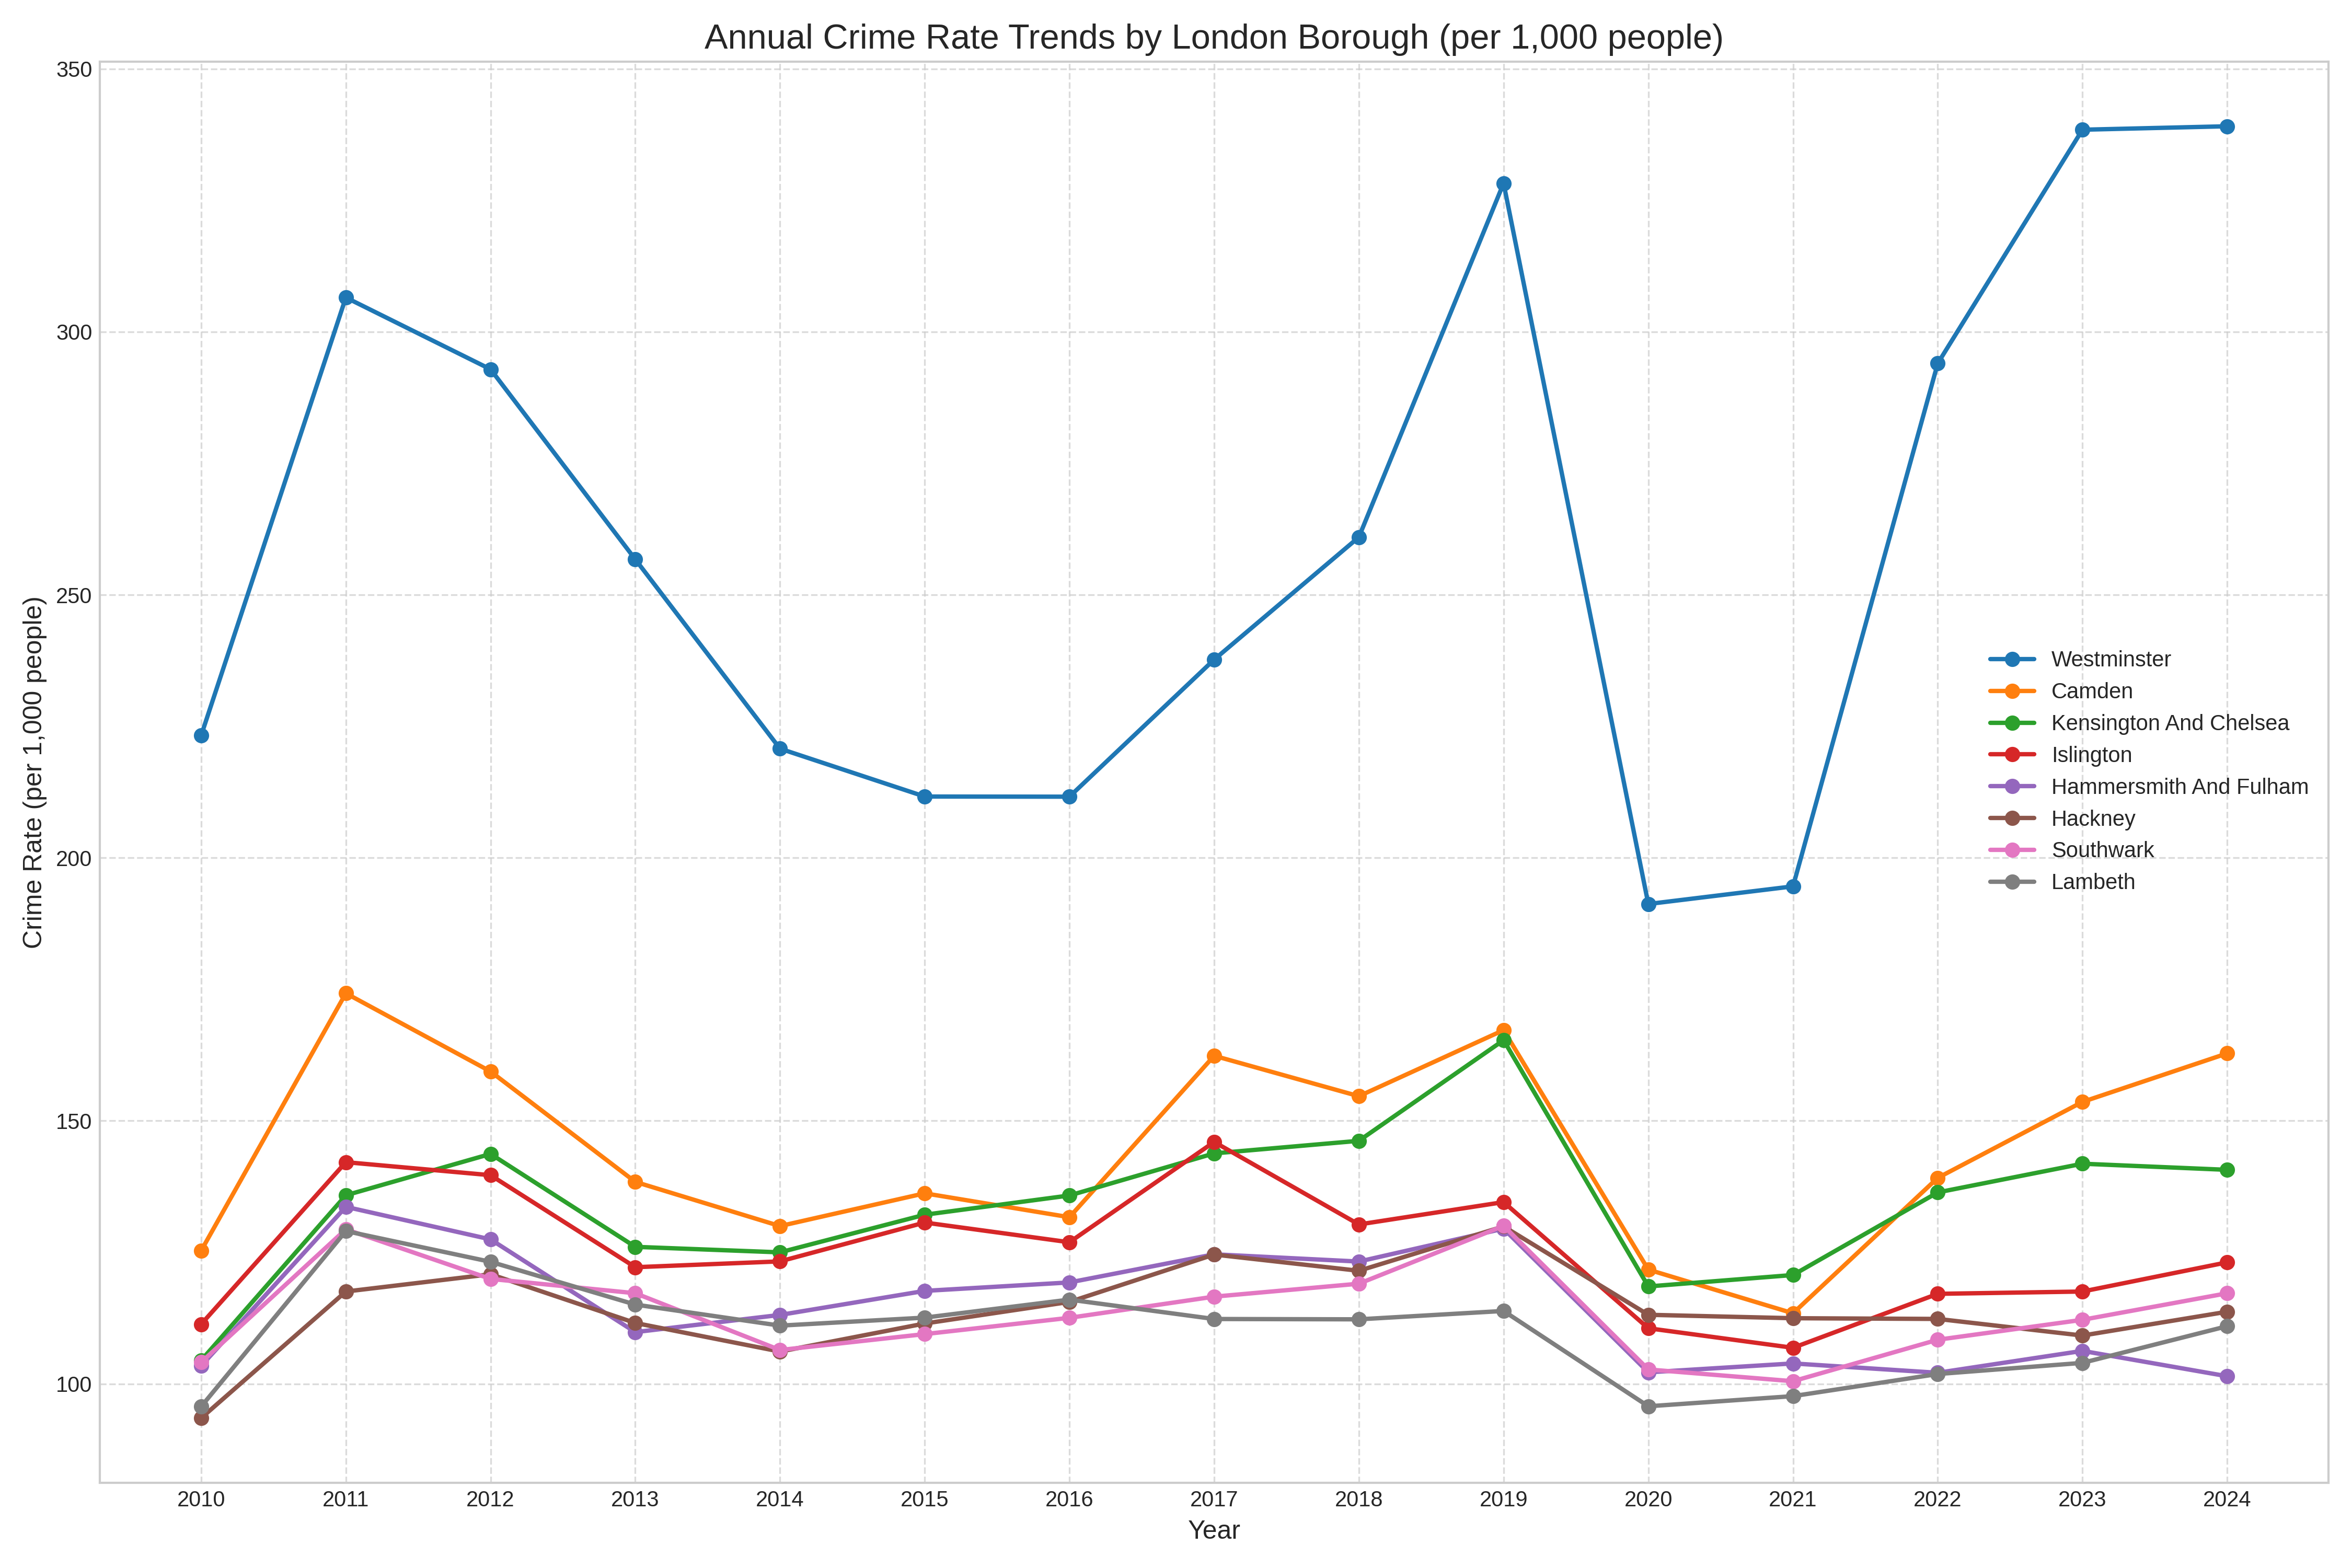

In [7]:
# Set up matplotlib
plt.style.use('seaborn-v0_8-whitegrid')  # Use a clean, modern style

# Set file paths
yearly_file = "data/london_yearly_crime_rates.csv"

# Load data
yearly_df = pd.read_csv(yearly_file)
yearly_df = yearly_df[yearly_df['Year'] < 2025]
plt.figure(figsize=(15, 10))
boroughs = yearly_df['BoroughName'].unique()

top_boroughs = yearly_df.groupby('BoroughName')['CrimeRate_per_1000'].mean().nlargest(8).index.tolist()
print(f"Showing top 8 boroughs with highest average crime rates: {', '.join(top_boroughs)}")
for borough in top_boroughs:
    borough_data = yearly_df[yearly_df['BoroughName'] == borough]
    plt.plot(borough_data['Year'], borough_data['CrimeRate_per_1000'], marker='o', linewidth=2, label=borough)

plt.title('Annual Crime Rate Trends by London Borough (per 1,000 people)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Crime Rate (per 1,000 people)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.xticks(yearly_df['Year'].unique())
plt.tight_layout()

plt.savefig('data/london_borough_crime_rates.png', dpi=300)

from IPython.display import Image, display
display(Image('data/london_borough_crime_rates.png'))

plt.close()

From the line chart above, We could notice that Westminster consistently stands out with significantly higher rates compared to other boroughs. Other boroughs like Camden, Kensington and Chelsea, and Southwark show moderate increases over time, while areas such as Hackney and Islington have remained relatively stable. 

#### Feature Extraction for K-means

To support LSTM-based crime forecasting, we extracted features from monthly and yearly crime data to capture each London borough’s crime profile. 

The feature extraction for K-means clustering captures each London borough’s crime profile through 24 features, including trend slopes, seasonal strength, COVID-19 impact, and crime type distribution and diversity, which summarizing both temporal patterns and crime composition across boroughs.

In [8]:
def extract_clustering_features():
    """
    Extract features from London crime data for K-means clustering.
    These features capture various aspects of crime patterns across boroughs.
    """
    
    #  Load the relevant datasets
    monthly_borough = pd.read_csv('data/london_monthly_borough.csv')
    yearly_crime_rates = pd.read_csv('data/london_yearly_crime_rates.csv')
    crime_type_rates = pd.read_csv('data/london_yearly_crime_type_rates.csv')
    
    monthly_borough['Date'] = pd.to_datetime(monthly_borough['Date'])
    
    # Extract trend features
    trend_features = []
    
    for borough in monthly_borough['BoroughName'].unique():
        borough_data = monthly_borough[monthly_borough['BoroughName'] == borough].sort_values('Date')
        
        if len(borough_data) >= 24:  # Need enough data points
            # Get borough time series
            borough_ts = pd.Series(
                borough_data['CrimeRate_per_1000'].values,
                index=pd.to_datetime(borough_data['Date'])
            )
            
            # Calculate trend slope using linear regression
            x = np.arange(len(borough_ts))
            if len(x) > 0:
                slope = np.polyfit(x, borough_ts, 1)[0]
            else:
                slope = 0
                
            # Calculate time series statistics
            avg_rate = borough_ts.mean()
            volatility = borough_ts.std()
            max_rate = borough_ts.max()
            min_rate = borough_ts.min()
            range_rate = max_rate - min_rate
            
            # Try to calculate seasonal features
            try:
                # Decompose time series
                decomposition = seasonal_decompose(borough_ts, model='multiplicative', period=12)
                seasonal = decomposition.seasonal
                residual = decomposition.resid
                
                # Calculate seasonal strength
                if (seasonal.dropna() + residual.dropna()).var() > 0:
                    seasonal_strength = 1 - (residual.dropna().var() / (seasonal.dropna() + residual.dropna()).var())
                else:
                    seasonal_strength = 0
                
                # Calculate monthly patterns
                monthly_avg = borough_data.groupby('Month')['CrimeRate_per_1000'].mean()
                peak_month = monthly_avg.idxmax()
                monthly_variation = monthly_avg.std() / monthly_avg.mean() if monthly_avg.mean() > 0 else 0
                
            except Exception as e:
                print(f"Error calculating seasonal features for {borough}: {e}")
                seasonal_strength = 0
                peak_month = 0
                monthly_variation = 0
            
            # Calculate COVID impact
            pre_covid = borough_data[borough_data['Date'] < '2020-03-01']['CrimeRate_per_1000'].mean()
            during_covid = borough_data[(borough_data['Date'] >= '2020-03-01') & 
                                       (borough_data['Date'] <= '2021-07-01')]['CrimeRate_per_1000'].mean()
            post_covid = borough_data[borough_data['Date'] > '2021-07-01']['CrimeRate_per_1000'].mean()
            
            covid_impact = (during_covid - pre_covid) / pre_covid if pre_covid > 0 else 0
            recovery_rate = (post_covid - during_covid) / during_covid if during_covid > 0 else 0
            
            # Calculate recent trend (last 2 years)
            recent_data = borough_data[borough_data['Date'] >= '2021-01-01']
            if len(recent_data) > 12:
                x_recent = np.arange(len(recent_data))
                recent_rates = recent_data['CrimeRate_per_1000'].values
                recent_slope = np.polyfit(x_recent, recent_rates, 1)[0]
            else:
                recent_slope = 0
            
            # Add features to the list
            trend_features.append({
                'BoroughName': borough,
                'trend_slope': slope,
                'recent_trend': recent_slope,
                'avg_crime_rate': avg_rate,
                'volatility': volatility,
                'range_crime_rate': range_rate,
                'seasonal_strength': seasonal_strength,
                'peak_month': peak_month,
                'monthly_variation': monthly_variation,
                'covid_impact': covid_impact,
                'recovery_rate': recovery_rate
            })
    
    # Create a dataframe of trend features
    trend_df = pd.DataFrame(trend_features)
    
    #  Extract crime type distribution features
    # Calculate percentage of each crime type per borough
    type_distribution = crime_type_rates.groupby(['BoroughName', 'MajorText'])['CrimeCount'].sum().reset_index()
    type_distribution['total_crimes'] = type_distribution.groupby('BoroughName')['CrimeCount'].transform('sum')
    type_distribution['percentage'] = type_distribution['CrimeCount'] / type_distribution['total_crimes'] * 100
    
    type_pivot = type_distribution.pivot(index='BoroughName', columns='MajorText', values='percentage').fillna(0)
    
    # Calculate crime type diversity (entropy)
    def entropy(row):
        non_zero = row[row > 0] / 100  
        if len(non_zero) > 0:
            return -sum(non_zero * np.log2(non_zero))
        return 0
    
    type_pivot['crime_diversity'] = type_pivot.apply(entropy, axis=1)
    
    # Combine all features
    clustering_features = pd.merge(
        trend_df,
        type_pivot.reset_index(),
        on='BoroughName',
        how='left'
    )
    
    # Handle any remaining NaN values
    clustering_features = clustering_features.fillna(0)
    
    clustering_features.to_csv('data/borough_features_for_clustering.csv', index=False)
    
    print("Features saved to: data/borough_features_for_clustering.csv")
    
    return clustering_features

if __name__ == "__main__":
    # Run feature extraction
    features = extract_clustering_features()
    
    # Show summary of extracted features
    print("\nExtracted features summary:")
    print(f"Number of boroughs: {len(features)}")
    print(f"Number of features: {features.shape[1] - 1}")  # Excluding BoroughName
    
    # Display the first few rows
    print("\nSample features (first 5 boroughs):")
    print(features[['BoroughName', 'trend_slope', 'avg_crime_rate', 'seasonal_strength', 'crime_diversity']].head()) 

Features saved to: data/borough_features_for_clustering.csv

Extracted features summary:
Number of boroughs: 32
Number of features: 24

Sample features (first 5 boroughs):
            BoroughName  trend_slope  avg_crime_rate  seasonal_strength  \
0  Barking And Dagenham    -0.008001        7.877738           0.255284   
1                Barnet    -0.006141        6.290617           0.334462   
2                Bexley     0.004469        5.064671           0.239705   
3                 Brent    -0.004740        7.711720           0.364080   
4               Bromley    -0.003130        6.090528           0.242077   

   crime_diversity  
0         2.956873  
1         2.868944  
2         2.925747  
3         2.971684  
4         2.896793  


## Methodology

[[ go back to the top ]](#Table-of-contents)

| Variable                            | Type         | Description                                                             |Notes   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| Burglary crime rate                 | Numeric      | The burglary rate of MSOAs. Used as dependent variables in regression.  |   |
| Temperature                         | Numeric      | The daytime temperature                                                 |   |
| Indicator of Inner or Outer London  | Categorical  | Whether the MSOA is in Inner London.                                    |   |
| ......  | ......  | ......                                    |   |

### K-means Clustering

To identify regions exhibiting similar temporal crime patterns and spatial characteristics, K-Means clustering was applied to features extracted from historical crime data.Temporal features included metrics like mean, variance, and seasonality, while spatial features captured location and urban context. The optimal number of clusters was selected using the elbow method. 

### LSTM Model

Following the clustering process, a dedicated Long Short-Term Memory (LSTM) model was developed for each identified region group to capture the temporal dependencies in crime rates more effectively. LSTM models use a gate mechanism to retain relevant information over time, allowing them to learn patterns in sequential data as it progresses through each step (Mishra et al., 2024). This study trained LSTM models on monthly crime data from January 2010 to March 2023, using a sliding window to retain temporal structure. Data were normalized before training to improve convergence. Model performance was assessed on the period from April 2023 to March 2025 using RMSE and MAE. 

- Workflow of Analysis

![Workflow of Analysis](data/visualizations/Method_workflow.png) 

## Analysis  

### Elbow Method

To determine the optimal number of clusters for K-Means, the Elbow Method was applied by computing the within-cluster sum of squares (inertia) for k values ranging from 1 to 15. The resulting curve helped identify points where adding more clusters yields diminishing returns in variance reduction. These “elbow” points, estimated via second-order differences, suggest an efficient trade-off between model complexity and compactness.

Loading and preparing data...
Calculating inertia for k=1 to k=15...
For k=1, inertia: 768.00
For k=2, inertia: 524.92
For k=3, inertia: 407.09
For k=4, inertia: 346.22
For k=5, inertia: 309.23
For k=6, inertia: 272.01
For k=7, inertia: 248.02
For k=8, inertia: 220.93
For k=9, inertia: 201.09
For k=10, inertia: 174.31
For k=11, inertia: 155.82
For k=12, inertia: 140.97
For k=13, inertia: 126.90
For k=14, inertia: 110.90
For k=15, inertia: 102.39
Elbow method analysis saved to: data/visualizations/elbow_method_analysis.png


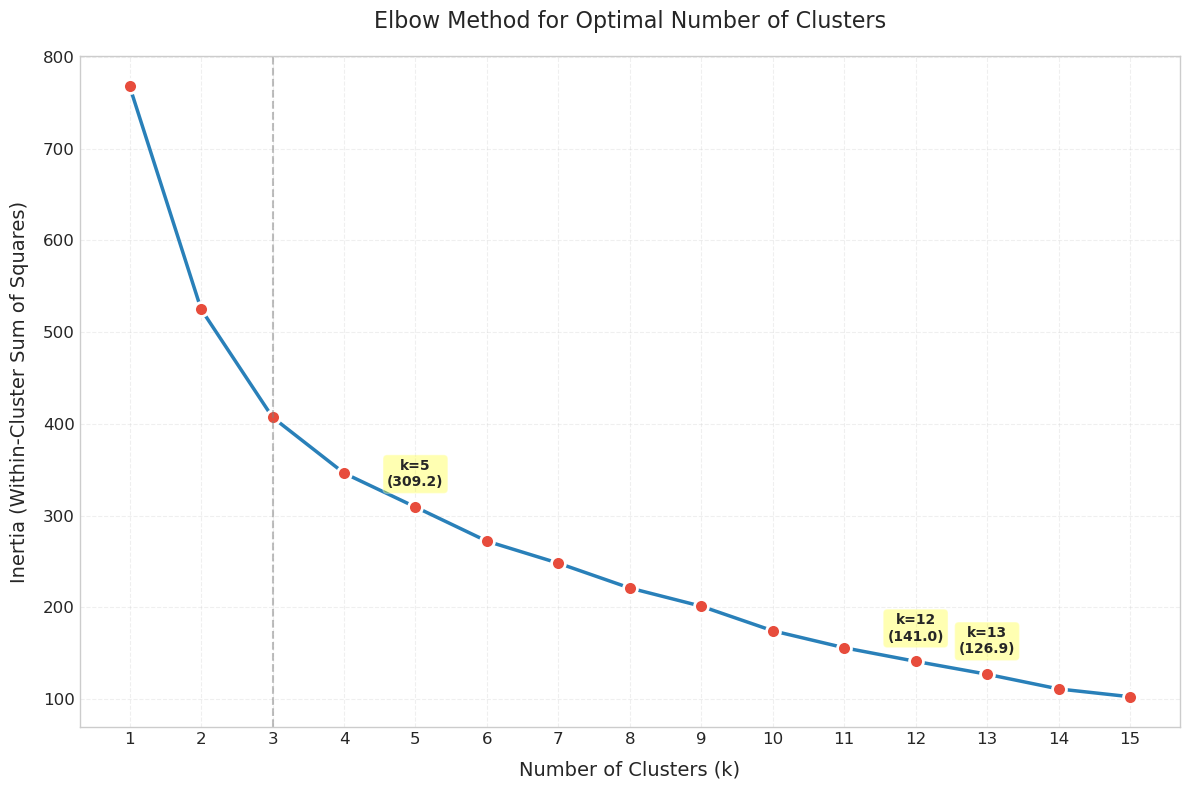

In [20]:
os.makedirs('data/visualizations', exist_ok=True)

print("Loading and preparing data...")
features_df = pd.read_csv('data/borough_features_for_clustering.csv')
borough_names = features_df['BoroughName'].values
# Prepare features for clustering
features_for_clustering = features_df.drop('BoroughName', axis=1)
feature_names = features_for_clustering.columns
# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_clustering)
# Calculate inertia (within-cluster sum of squares) for different k values
print("Calculating inertia for k=1 to k=15...")
inertia_values = []
k_range = range(1, 16)  
for k in k_range:
    if k == 1:
        inertia = np.sum(np.square(features_scaled - np.mean(features_scaled, axis=0)))
        inertia_values.append(inertia)
    else:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(features_scaled)
        inertia_values.append(kmeans.inertia_)
    print(f"For k={k}, inertia: {inertia_values[-1]:.2f}")
# Create enhanced Elbow plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
# Plot inertia values with attractive styling
plt.plot(k_range, inertia_values, 'o-', linewidth=2.5, markersize=10, 
         color='#2980b9', markerfacecolor='#e74c3c', markeredgecolor='white', 
         markeredgewidth=2)
# Add annotations for key points
deltas = np.diff(inertia_values)
delta_deltas = np.diff(deltas)
elbow_indices = np.argsort(np.abs(delta_deltas))[:3] + 1  # +1 due to double diff
for idx in elbow_indices:
    plt.annotate(f'k={k_range[idx]}\n({inertia_values[idx]:.1f})', 
                 (k_range[idx], inertia_values[idx]),
                 textcoords="offset points", 
                 xytext=(0,15), 
                 ha='center',
                 fontsize=10,
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=16, pad=20)
plt.xlabel('Number of Clusters (k)', fontsize=14, labelpad=10)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=14, labelpad=10)
plt.xticks(k_range, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
# Add vertical line ONLY at k=3 (chosen cluster)
plt.axvline(x=3, color='gray', linestyle='--', alpha=0.5)
# Add a note about interpretation
plt.figtext(0.5, 0.01, 
            "", 
            ha="center", fontsize=12, 
            bbox={"facecolor":"lightgrey", "alpha":0.5, "pad":5})
plt.tight_layout()
plt.savefig('data/visualizations/elbow_method_analysis.png', dpi=300, bbox_inches='tight')
print("Elbow method analysis saved to: data/visualizations/elbow_method_analysis.png")

According to the Elbow Method, k=3 was selected as the optimal number of clusters. While lower inertia values were observed with higher k, the rate of decrease significantly diminished beyond k=3, indicating that additional clusters contributed marginal explanatory power. 

### Perform K-means Clustering 

To perform K-means clustering, a mix of time-series and structural features was capucured to represent each borough’s crime profile. This included long-term and recent trends in crime rates, seasonal strength, and how crime changed during and after the COVID-19 period. Also,the composition of crime types in each borough were considered, calculating the percentage share of each major category and an overall diversity score using entropy.

Performing K-means clustering with k=3...


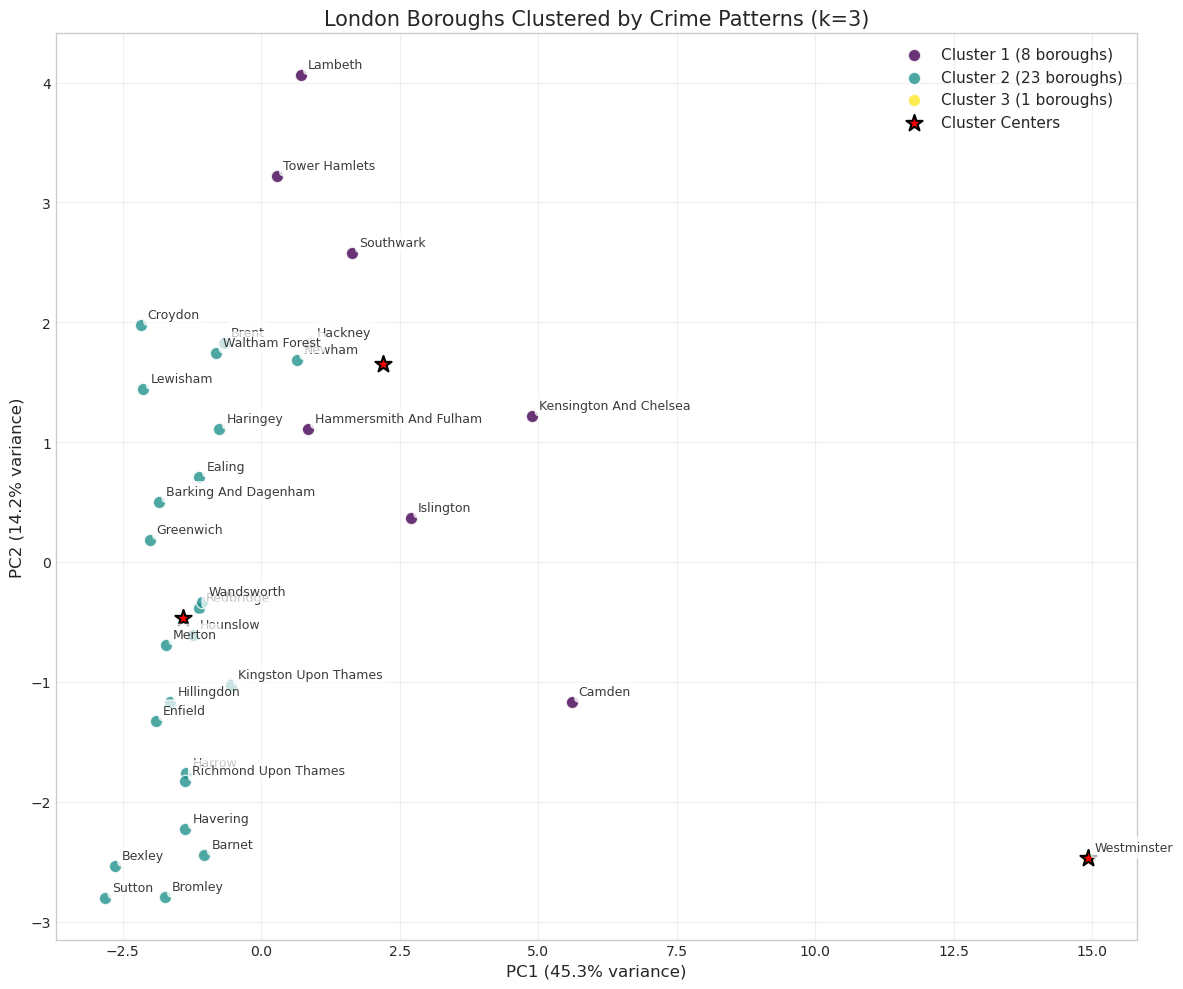

In [21]:
# Set cluster count - change this based on your analysis
K = 3

# Load and prepare data
print(f"Performing K-means clustering with k={K}...")
features_df = pd.read_csv('data/borough_features_for_clustering.csv')
borough_names = features_df['BoroughName'].values

# Prepare and standardize features
features = features_df.drop('BoroughName', axis=1)
feature_names = features.columns
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform K-means clustering
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

# Add cluster labels to features dataframe
clustered_data = features_df.copy()
clustered_data['cluster'] = cluster_labels

# Create borough-to-cluster mapping
cluster_mapping = pd.DataFrame({
    'BoroughName': borough_names,
    'cluster': cluster_labels
})

# Save clustering results
os.makedirs('data/visualizations', exist_ok=True)
clustered_data.to_csv('data/london_borough_clusters.csv', index=False)
cluster_mapping.to_csv('data/london_cluster_mapping.csv', index=False)

# Save cluster centers for interpretation
cluster_centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_names
)
cluster_centers_original.to_csv('data/london_cluster_centers.csv', index=False)

# Create PCA visualization
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)
variance_explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, K))

# Plot clusters
for i in range(K):
    cluster_points = features_pca[cluster_labels == i]
    plt.scatter(
        cluster_points[:, 0], 
        cluster_points[:, 1],
        s=80, 
        alpha=0.8, 
        c=[colors[i]], 
        edgecolor='white',
        linewidth=1,
        label=f'Cluster {i+1} ({np.sum(cluster_labels == i)} boroughs)'
    )

# Add borough labels
for i, borough in enumerate(borough_names):
    plt.annotate(
        borough, 
        (features_pca[i, 0], features_pca[i, 1]),
        fontsize=9,
        alpha=0.9,
        xytext=(5, 5),
        textcoords='offset points',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
    )

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers_pca[:, 0], 
    centers_pca[:, 1],
    s=150, 
    marker='*', 
    c='red', 
    edgecolor='black',
    linewidth=1.5,
    label='Cluster Centers'
)

plt.title(f'London Boroughs Clustered by Crime Patterns (k={K})', fontsize=15)
plt.xlabel(f'PC1 ({variance_explained[0]:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({variance_explained[1]:.1f}% variance)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/visualizations/borough_clusters_pca.png', dpi=300)


Creating map visualization with swapped blue and green colors...
Map with swapped blue and green colors saved to: data/visualizations/london_clusters_map_swapped_colors.png


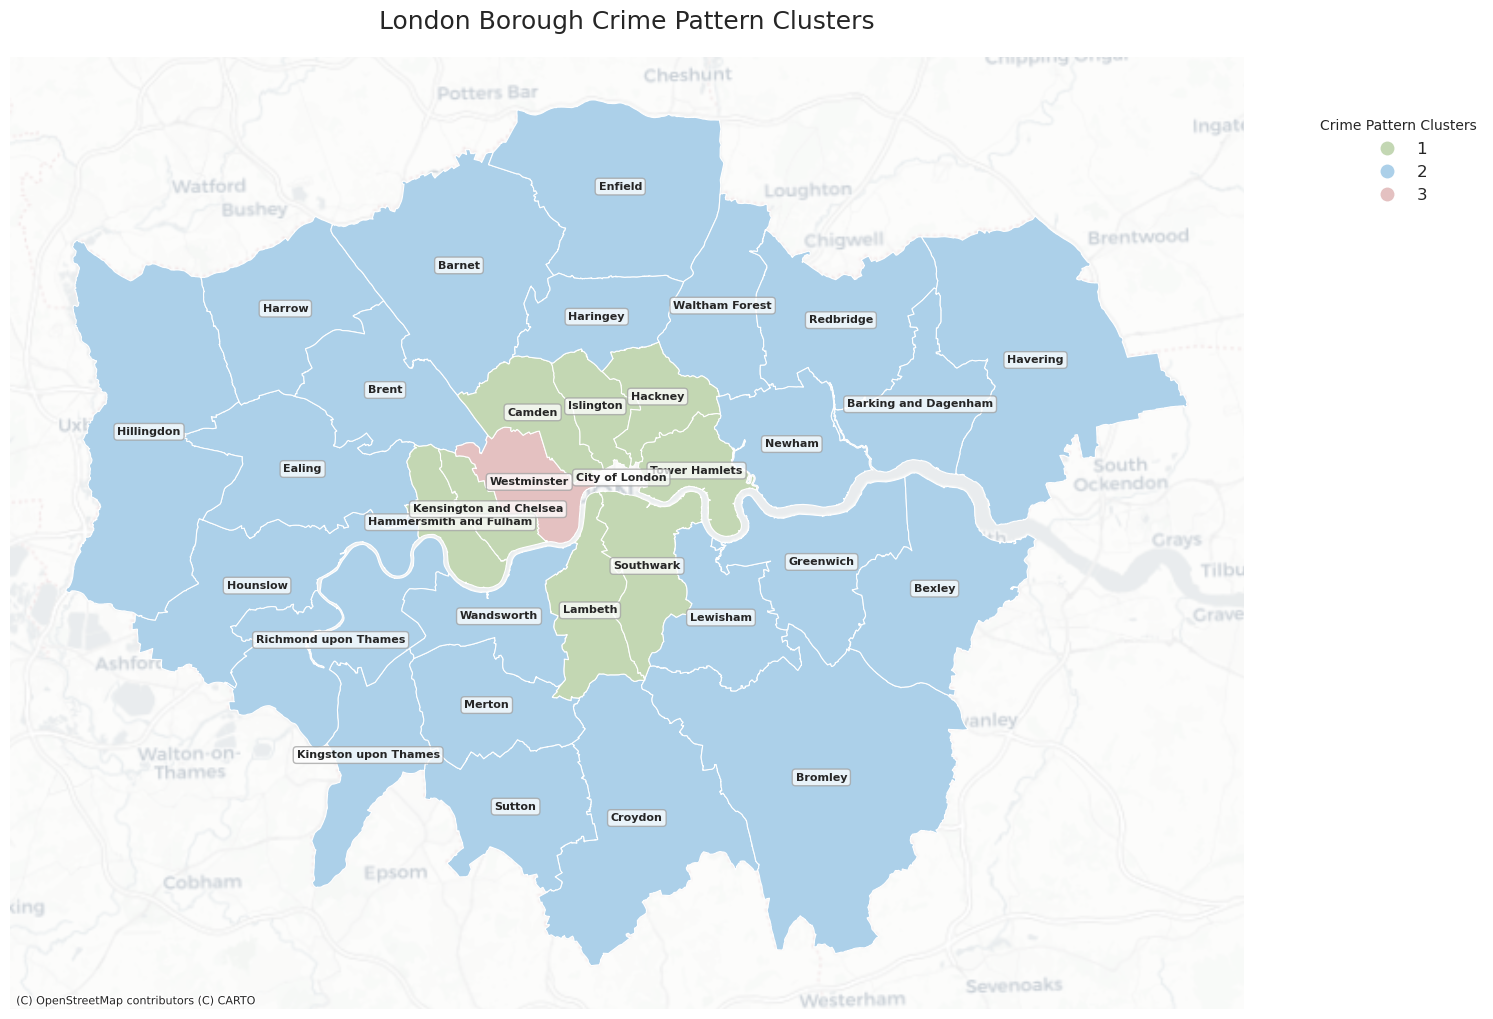

In [19]:
# Load shapefile and cluster mapping
print("Creating map visualization with swapped blue and green colors...")
london_shape = gpd.read_file('data/ESRI/London_Borough_Excluding_MHW.shp')
clusters = pd.read_csv('data/london_cluster_mapping.csv')

# Standardize borough names for matching
london_shape['NAME_lower'] = london_shape['NAME'].str.lower().str.strip()
clusters['BoroughName_lower'] = clusters['BoroughName'].str.lower().str.strip()

# Merge data
london_clusters = london_shape.merge(
    clusters,
    left_on='NAME_lower',
    right_on='BoroughName_lower',
    how='left'
)

# Check for unmatched boroughs
unmatched = london_clusters[london_clusters['cluster'].isna()]
if not unmatched.empty:
    print(f"Warning: {len(unmatched)} unmatched boroughs: {unmatched['NAME'].tolist()}")

# Create directory for output
os.makedirs('data/visualizations', exist_ok=True)

# Create visually appealing map
fig, ax = plt.subplots(figsize=(15, 12))

# Get number of clusters
n_clusters = london_clusters['cluster'].nunique()

# Create a color palette with swapped blue and green regions
elegant_distinct_colors = [
    '#c3d7b3', 
    '#acd0e9',  
    '#e4c1c1',  
    '#8bbcaa',  
    '#d1c39f',  
    '#728fb8',  
    '#b5a0c9',  
    '#dab89f',  
    '#6d9ea3',  
    '#c99f9f',  
]

# Ensure we have enough colors for all clusters
while len(elegant_distinct_colors) < n_clusters:
    elegant_distinct_colors.extend(elegant_distinct_colors)
elegant_distinct_colors = elegant_distinct_colors[:n_clusters]

cmap = LinearSegmentedColormap.from_list('elegant_distinct_swapped', elegant_distinct_colors, N=n_clusters)

london_clusters.plot(
    column='cluster',
    cmap=cmap,
    linewidth=0.8,
    edgecolor='white',
    ax=ax,
    legend=True,
    categorical=True,
    legend_kwds={
        'title': 'Crime Pattern Clusters',
        'bbox_to_anchor': (1.05, 0.95),
        'loc': 'upper left',
        'fontsize': 12,
        'labels': ['1', '2', '3']  # Modified labels: 0→1, 1→2, 2→3
    }
)

for idx, row in london_clusters.iterrows():
    centroid = row['geometry'].centroid
    
    ax.text(
        centroid.x, 
        centroid.y, 
        row['NAME'],
        fontsize=8,
        ha='center',
        va='center',
        fontweight='bold',
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc='white',
            ec='#a0a0a0',
            alpha=0.75
        )
    )

# Add basemap for context
try:
    ctx.add_basemap(
        ax,
        crs=london_clusters.crs.to_string(),
        source=ctx.providers.CartoDB.Positron,
        alpha=0.5
    )
except Exception as e:
    print(f"Could not add basemap: {e}")

plt.title('London Borough Crime Pattern Clusters', fontsize=18, pad=20)
plt.axis('off')
plt.tight_layout()

output_path = 'data/visualizations/london_clusters_map_swapped_colors.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Map with swapped blue and green colors saved to: {output_path}")

The K-means clustering analysis of London boroughs revealed three distinct crime pattern clusters. Cluster 1 comprising eight inner London boroughs characterized by dense urban environments; Cluster 2 containing 23 outer London boroughs showing relatively homogeneous crime patterns despite their geographical spread; and Cluster 3 consisting solely of Westminster, which displays unique crime characteristics. Based on the initial data, Westminster exhibits significantly higher crime rates compared to other London areas.

### LSTM Model 

![LSTM model workflow](data/visualizations/LSTM_workflow.png)

#### LSTM data preparation

To model temporal crime patterns, monthly crime rates were averaged within each spatial cluster to form representative time series. A 12-month sliding window was used to predict the following month. Models were trained on data from April 2010 to March 2023 and tested on April 2023 to March 2025 using a rolling forecast.

In [29]:
def prepare_lstm_data(train_data, test_data, output_dir, name_prefix, value_column, seq_length=12):
    """
    Prepare sequence data for LSTM model with complete test sequence coverage
    
    Args:
        train_data: Training data DataFrame
        test_data: Testing data DataFrame
        output_dir: Output directory
        name_prefix: File name prefix
        value_column: Value column name
        seq_length: Sequence length (default is 12 months)
    """
    print(f"Train data shape: {train_data.shape}, Test data shape: {test_data.shape}")
    
    # Use MinMaxScaler for data normalization
    scaler = MinMaxScaler()
    train_scaled = pd.DataFrame(
        scaler.fit_transform(train_data[[value_column]]),
        columns=[value_column]
    )
    test_scaled = pd.DataFrame(
        scaler.transform(test_data[[value_column]]),
        columns=[value_column]
    )
    
    # Create training sequences using traditional method
    def create_train_sequences(data, seq_length=12):
        """Create sequence data for LSTM training"""
        X, y = [], []
        data_array = data[value_column].values
        for i in range(len(data_array) - seq_length):
            X.append(data_array[i:i+seq_length])
            y.append(data_array[i+seq_length])
        return np.array(X), np.array(y)
    
    # Create test sequences using a rolling forecast approach
    def create_rolling_test_sequences(train_data, test_data, seq_length=12):
        """
        Create test sequences using rolling forecast approach
        This ensures we have predictions for ALL test months
        """
        train_values = train_data[value_column].values
        test_values = test_data[value_column].values
        
        X, y = [], []
        input_sequence = train_values[-seq_length:]
        
        # For each test value, create a prediction sequence and then update the sequence
        for i in range(len(test_values)):
            X.append(input_sequence.copy())
            
            y.append(test_values[i])
            
            input_sequence = np.append(input_sequence[1:], test_values[i])
        
        return np.array(X), np.array(y)
    
    X_train, y_train = create_train_sequences(train_scaled, seq_length)
    
    X_test, y_test = create_rolling_test_sequences(train_scaled, test_scaled, seq_length)
    
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
    print(f"Number of test months: {len(test_data)}")
    print(f"Number of test sequences created: {len(X_test)}")
    
    # Verify that we have a sequence for each test month
    if len(X_test) != len(test_data):
        print(f"WARNING: Number of test sequences ({len(X_test)}) does not match number of test months ({len(test_data)})")
    else:
        print(f"SUCCESS: Created a sequence for each test month ({len(test_data)} months)")
    
    # Check if training data is sufficient
    if len(X_train) == 0:
        print(f"  Warning: Not enough training data for {name_prefix}")
        return
    
    np.save(f'{output_dir}/X_train.npy', X_train)
    np.save(f'{output_dir}/y_train.npy', y_train)
    np.save(f'{output_dir}/X_test.npy', X_test)
    np.save(f'{output_dir}/y_test.npy', y_test)
    
    # Save scaler for later denormalization
    with open(f'{output_dir}/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    
    # Save the original test data for date reference
    test_data.to_csv(f'{output_dir}/original_test.csv', index=False)
    
    # Save sequence details for debugging
    with open(f'{output_dir}/sequence_details.txt', 'w') as f:
        f.write(f"Train period: {train_data['Date'].min()} to {train_data['Date'].max()}, {len(train_data)} months\n")
        f.write(f"Test period: {test_data['Date'].min()} to {test_data['Date'].max()}, {len(test_data)} months\n")
        f.write(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}\n")
        f.write(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}\n")
        
        # Save first few sequences for verification
        f.write("\nFirst 3 test sequences (if available):\n")
        for i in range(min(3, len(X_test))):
            sequence_dates = test_data['Date'].iloc[i:i+1].tolist()
            f.write(f"Sequence {i}, Target date: {sequence_dates[0]}\n")
        
        # Save last few sequences for verification
        f.write("\nLast 3 test sequences (if available):\n")
        for i in range(max(0, len(X_test)-3), len(X_test)):
            sequence_dates = test_data['Date'].iloc[i:i+1].tolist()
            f.write(f"Sequence {i}, Target date: {sequence_dates[0]}\n")

# Main program starts 
# Load time series data (organized by borough and crime type)
ts_data = pd.read_csv('data/london_crime_ts_data.csv')
ts_data['Date'] = pd.to_datetime(ts_data['Date'])

# Load clustering results
clusters_data = pd.read_csv('data/london_borough_clusters.csv')
# Get number of clusters
K = clusters_data['cluster'].nunique()
print(f"Found {K} borough clusters")

# Create LSTM data directory
lstm_dir = 'data/lstm_by_cluster'
os.makedirs(lstm_dir, exist_ok=True)

# Ensure we have data through March 2025
max_date = ts_data['Date'].max()
expected_end_date = pd.to_datetime('2025-03-01')

if max_date < expected_end_date:
    print(f"Warning: Data only goes up to {max_date.strftime('%Y-%m-%d')}, not {expected_end_date.strftime('%Y-%m-%d')}")

# Prepare data for each cluster
print("Preparing LSTM data by cluster...")
for cluster_id in range(K):
    print(f"Processing cluster {cluster_id}...")
    
    cluster_boroughs = clusters_data[clusters_data['cluster'] == cluster_id]['BoroughName'].tolist()
    
    cluster_dir = f"{lstm_dir}/cluster_{cluster_id+1}"
    os.makedirs(cluster_dir, exist_ok=True)
    
    cluster_data = ts_data[ts_data['BoroughName'].isin(cluster_boroughs)]
    
    agg_data = cluster_data.groupby('Date')['TotalCrimeRate'].mean().reset_index()
    agg_data.rename(columns={'TotalCrimeRate': 'CrimeRate'}, inplace=True)
    
    # Split into training and testing data - use April 2023 as the split date
    split_date = pd.to_datetime('2023-04-01')
    train_data = agg_data[agg_data['Date'] < split_date]
    test_data = agg_data[agg_data['Date'] >= split_date]
    
    print(f"Train period: {train_data['Date'].min()} to {train_data['Date'].max()}, {len(train_data)} months")
    print(f"Test period: {test_data['Date'].min()} to {test_data['Date'].max()}, {len(test_data)} months")
    
    # Save overall data for this cluster
    agg_data.to_csv(f'{cluster_dir}/total_crime_rate.csv', index=False)
    train_data.to_csv(f'{cluster_dir}/train.csv', index=False)
    test_data.to_csv(f'{cluster_dir}/test.csv', index=False)
    
    # Create sequence data for LSTM
    prepare_lstm_data(
        train_data, test_data, 
        cluster_dir, 'total', 
        'CrimeRate', 12
    )
    
    print(f"LSTM data for cluster {cluster_id+1} prepared successfully")

print("\nCluster Summary:")
for cluster_id in range(K):
    cluster_boroughs = clusters_data[clusters_data['cluster'] == cluster_id]['BoroughName'].tolist()
    print(f"Cluster {cluster_id+1}: {len(cluster_boroughs)} boroughs")
    print(f"  {', '.join(cluster_boroughs)}")

print(f"\nLSTM model data saved to {lstm_dir}/")

Found 3 borough clusters
Preparing LSTM data by cluster...
Processing cluster 0...
Train period: 2010-04-01 00:00:00 to 2023-03-01 00:00:00, 156 months
Test period: 2023-04-01 00:00:00 to 2025-03-01 00:00:00, 24 months
Train data shape: (156, 2), Test data shape: (24, 2)
X_train shape: (144, 12), y_train shape: (144,)
X_test shape: (24, 12), y_test shape: (24,)
Number of test months: 24
Number of test sequences created: 24
SUCCESS: Created a sequence for each test month (24 months)
LSTM data for cluster 1 prepared successfully
Processing cluster 1...
Train period: 2010-04-01 00:00:00 to 2023-03-01 00:00:00, 156 months
Test period: 2023-04-01 00:00:00 to 2025-03-01 00:00:00, 24 months
Train data shape: (156, 2), Test data shape: (24, 2)
X_train shape: (144, 12), y_train shape: (144,)
X_test shape: (24, 12), y_test shape: (24,)
Number of test months: 24
Number of test sequences created: 24
SUCCESS: Created a sequence for each test month (24 months)
LSTM data for cluster 2 prepared succes

#### Tranning LSTM model

To improve temporal prediction accuracy, separate LSTM models were trained for each cluster. Cluster 3 (Westminster) uses a deeper architecture with bidirectional LSTM and attention mechanisms to better capture complex temporal dynamics. For Clusters 1 and 2, a multi-path LSTM design was applied to account for both short-term and long-term patterns.

Data augmentation techniques such as noise injection and temporal shifts—were used in clusters with limited or unstable data to enhance model robustness. While the models focus on time series, clustering ensures that regional differences are indirectly considered through tailored training for each group.


Processing Cluster 1
X_train shape: (144, 12), y_train shape: (144,)
X_test shape: (24, 12), y_test shape: (24,)
Using enhanced multi-region specialized model for Cluster 1
Using specialized training for multi-region cluster
Advanced augmented training data: (144, 12, 1) → (864, 12, 1)
Augmented target data: (144, 1) → (864, 1)
Epoch 1/120

Epoch 1: val_loss improved from inf to 0.30377, saving model to data/lstm_by_cluster/cluster_1/best_model.keras
195/195 - 11s - 56ms/step - loss: 0.3779 - mae: 0.1825 - val_loss: 0.3038 - val_mae: 0.1577 - learning_rate: 0.0010
Epoch 2/120

Epoch 2: val_loss improved from 0.30377 to 0.22417, saving model to data/lstm_by_cluster/cluster_1/best_model.keras
195/195 - 2s - 10ms/step - loss: 0.2546 - mae: 0.1246 - val_loss: 0.2242 - val_mae: 0.1335 - learning_rate: 0.0010
Epoch 3/120

Epoch 3: val_loss improved from 0.22417 to 0.16341, saving model to data/lstm_by_cluster/cluster_1/best_model.keras
195/195 - 2s - 10ms/step - loss: 0.1841 - mae: 0.1159 -

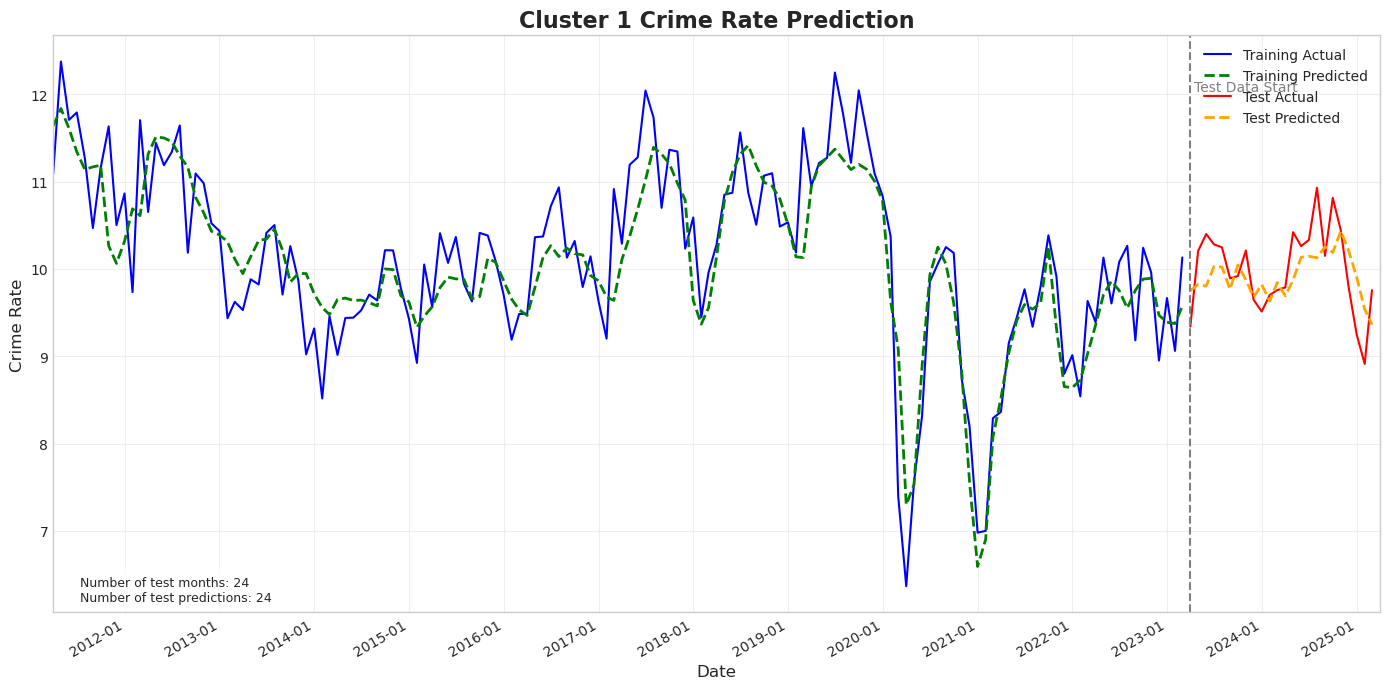

Last test date: 2025-03-01 00:00:00
Future date range: 2025-04-01 00:00:00 to 2026-03-01 00:00:00


<Figure size 1400x700 with 0 Axes>

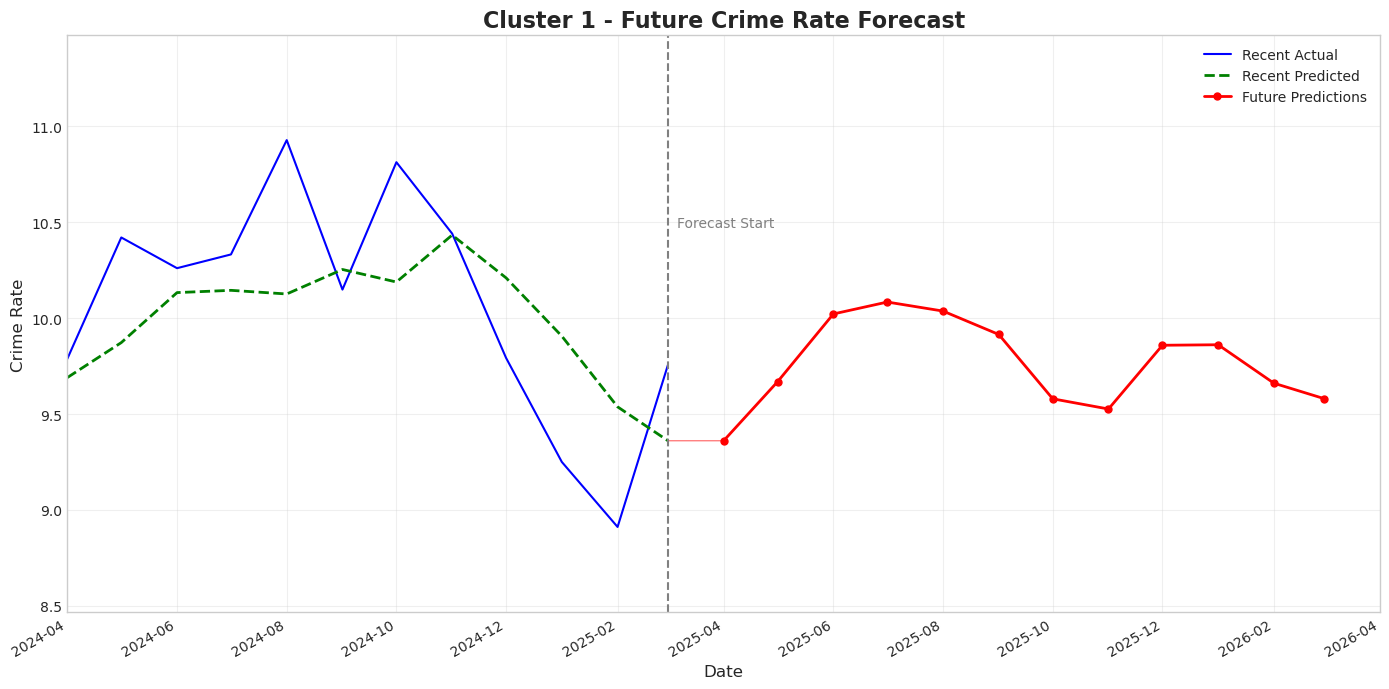


Processing Cluster 2
X_train shape: (144, 12), y_train shape: (144,)
X_test shape: (24, 12), y_test shape: (24,)
Using enhanced multi-region specialized model for Cluster 2
Using specialized training for multi-region cluster
Advanced augmented training data: (144, 12, 1) → (864, 12, 1)
Augmented target data: (144, 1) → (864, 1)
Epoch 1/120

Epoch 1: val_loss improved from inf to 0.29879, saving model to data/lstm_by_cluster/cluster_2/best_model.keras
195/195 - 11s - 57ms/step - loss: 0.3638 - mae: 0.1761 - val_loss: 0.2988 - val_mae: 0.1642 - learning_rate: 0.0010
Epoch 2/120

Epoch 2: val_loss improved from 0.29879 to 0.21117, saving model to data/lstm_by_cluster/cluster_2/best_model.keras
195/195 - 2s - 10ms/step - loss: 0.2462 - mae: 0.1309 - val_loss: 0.2112 - val_mae: 0.1403 - learning_rate: 0.0010
Epoch 3/120

Epoch 3: val_loss improved from 0.21117 to 0.14482, saving model to data/lstm_by_cluster/cluster_2/best_model.keras
195/195 - 2s - 12ms/step - loss: 0.1715 - mae: 0.1224 -

<Figure size 1400x700 with 0 Axes>

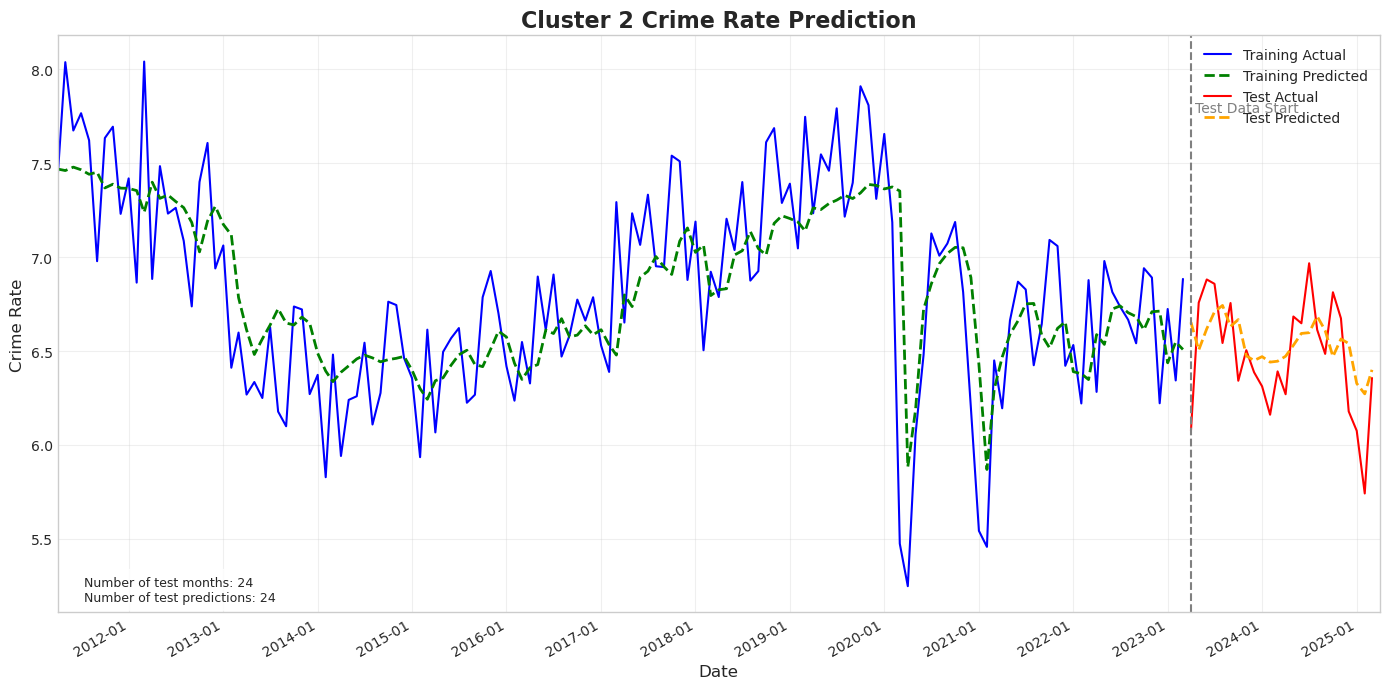

Last test date: 2025-03-01 00:00:00
Future date range: 2025-04-01 00:00:00 to 2026-03-01 00:00:00


<Figure size 1400x700 with 0 Axes>

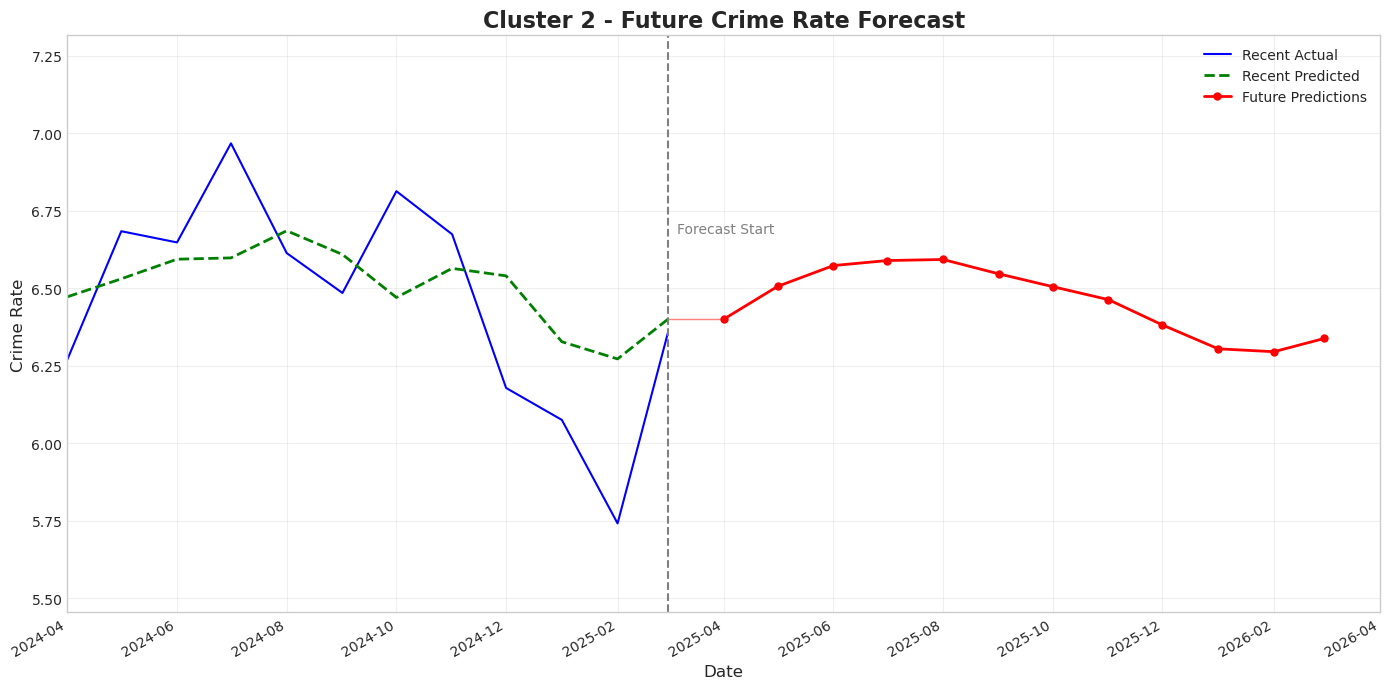


Processing Cluster 3
X_train shape: (144, 12), y_train shape: (144,)
X_test shape: (24, 12), y_test shape: (24,)
Using complex attention model for Cluster 3 (Westminster)
Using standard training for Cluster 3 (Westminster)
Epoch 1/50

Epoch 1: val_loss improved from inf to 0.06649, saving model to data/lstm_by_cluster/cluster_3/best_model.keras
4/4 - 6s - 2s/step - loss: 0.2311 - mae: 0.3468 - val_loss: 0.0665 - val_mae: 0.1952
Epoch 2/50

Epoch 2: val_loss improved from 0.06649 to 0.05347, saving model to data/lstm_by_cluster/cluster_3/best_model.keras
4/4 - 0s - 94ms/step - loss: 0.0303 - mae: 0.1411 - val_loss: 0.0535 - val_mae: 0.1822
Epoch 3/50

Epoch 3: val_loss did not improve from 0.05347
4/4 - 0s - 58ms/step - loss: 0.0372 - mae: 0.1598 - val_loss: 0.0549 - val_mae: 0.1900
Epoch 4/50

Epoch 4: val_loss improved from 0.05347 to 0.05300, saving model to data/lstm_by_cluster/cluster_3/best_model.keras
4/4 - 0s - 72ms/step - loss: 0.0282 - mae: 0.1288 - val_loss: 0.0530 - val_mae

<Figure size 1400x700 with 0 Axes>

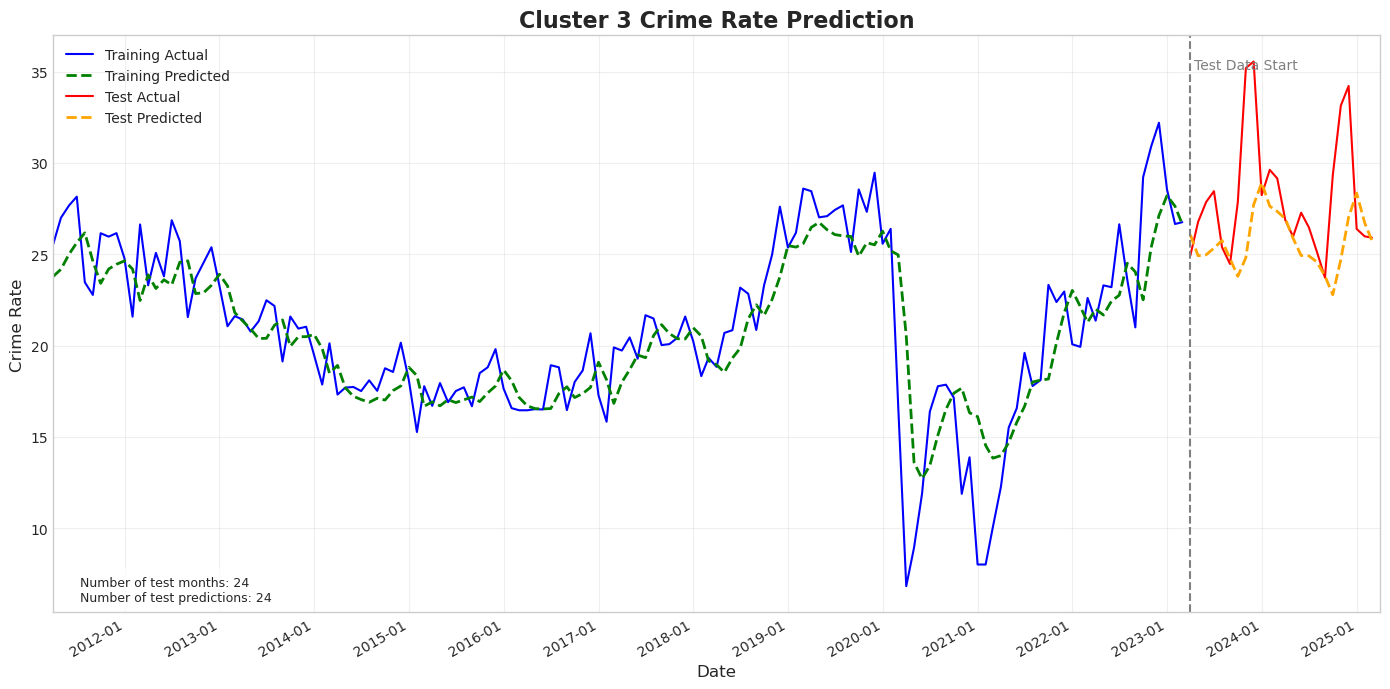

Last test date: 2025-03-01 00:00:00
Future date range: 2025-04-01 00:00:00 to 2026-03-01 00:00:00


<Figure size 1400x700 with 0 Axes>

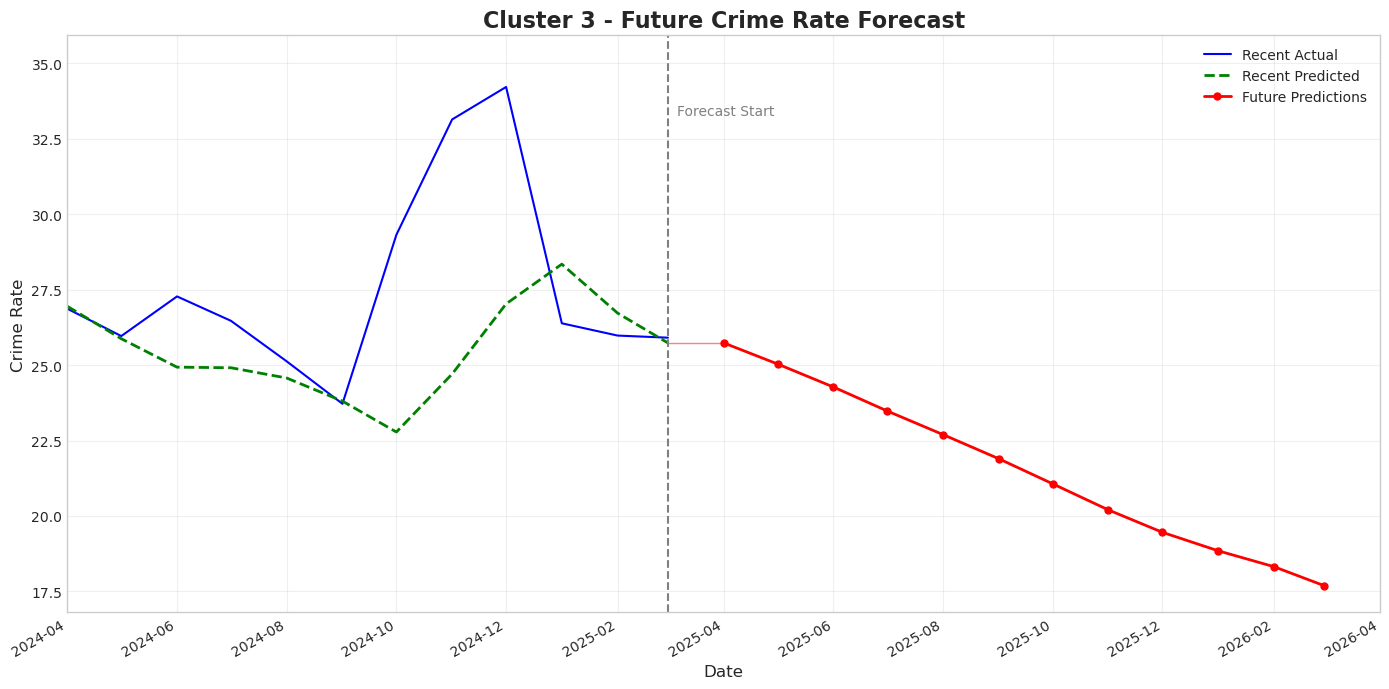

<Figure size 1400x700 with 0 Axes>

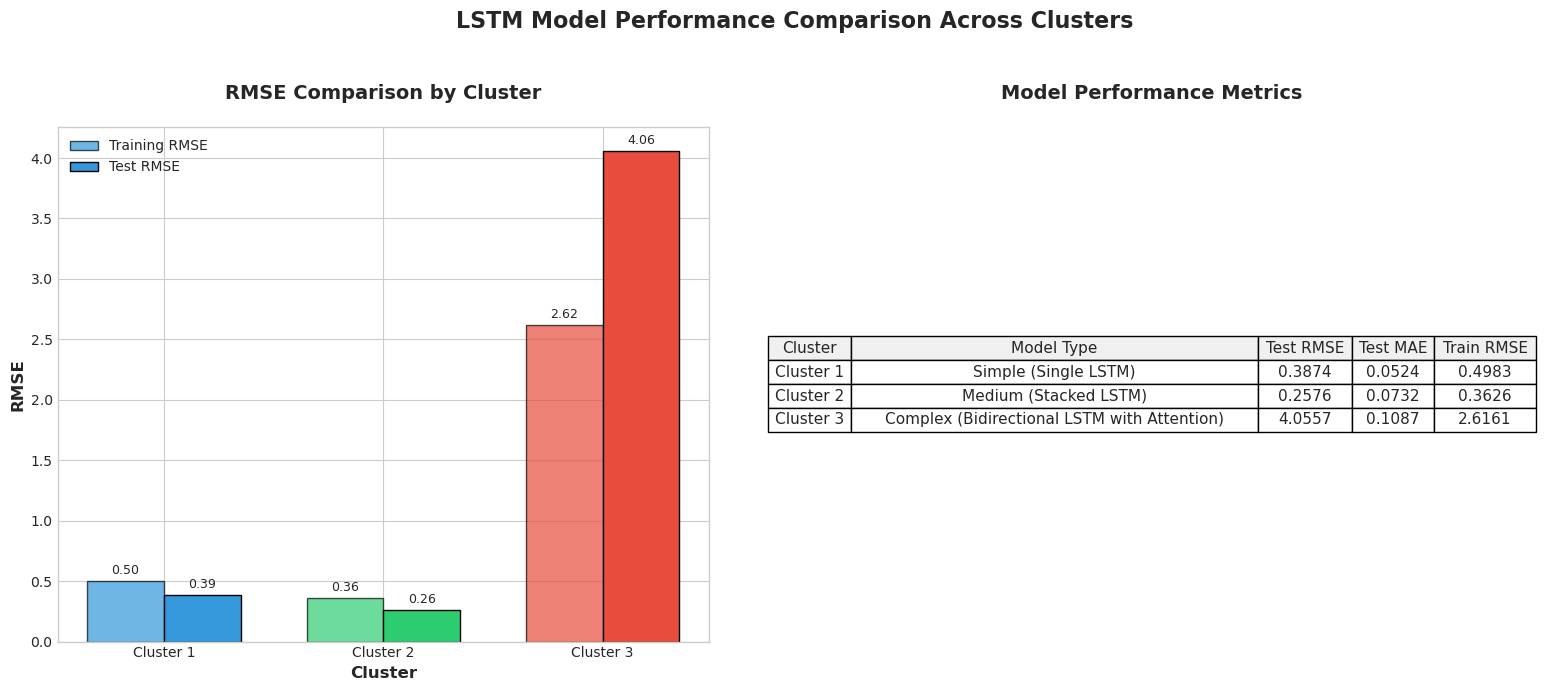


Model Evaluation Summary:
   ClusterID  TestRMSE   TestMAE  TestLoss  TrainRMSE  \
0          1  0.387390  0.052384  0.004202   0.498272   
1          2  0.257577  0.073152  0.007901   0.362636   
2          3  4.055679  0.108653  0.025535   2.616096   

                                     ModelType  
0                         Simple (Single LSTM)  
1                        Medium (Stacked LSTM)  
2  Complex (Bidirectional LSTM with Attention)  

LSTM model training and evaluation complete!


In [81]:
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Apply seaborn style for more beautiful plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.figsize': (14, 7),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# Enhanced model architectures with further specialization for each cluster
def build_multi_region_lstm_model(input_shape, units=96, dropout_rate=0.25):
    """
    Enhanced specialized model for multi-region clusters (Clusters 1 & 2)
    Designed to better capture volatility patterns in crime data
    """
    inputs = Input(shape=input_shape)
    
    # Parallel processing paths to capture different patterns
    # Captures short-term fluctuations
    short_term = LSTM(units, 
                     return_sequences=True,
                     recurrent_regularizer=tf.keras.regularizers.l2(0.0005))(inputs)
    short_term = LSTM(units//2, 
                     return_sequences=False,
                     recurrent_dropout=0.2)(short_term)
    short_term = Dropout(dropout_rate)(short_term)
    
    # Captures broader patterns with bidirectional processing
    broad_pattern = Bidirectional(LSTM(units//2, 
                                      return_sequences=True))(inputs)
    broad_pattern = Bidirectional(LSTM(units//4))(broad_pattern)
    broad_pattern = Dropout(dropout_rate)(broad_pattern)
    
    # Combine the paths
    combined = Concatenate()([short_term, broad_pattern])
    
    # Add attention mechanism to focus on important features
    attention_layer = Dense(units, activation='tanh')(combined)
    attention_weights = Dense(1, activation='sigmoid')(attention_layer)
    attention_output = Multiply()([combined, attention_weights])
    
    # Feature extraction layers
    x = Dense(64, activation='relu', 
             kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0005, l2=0.0005))(attention_output)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    # Add residual connection to preserve important features
    x = Dense(32, activation='relu')(x)
    x = Add()([x, Dense(32, activation='linear')(attention_output)])  # Residual connection
    
    # Final prediction layer
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

#  MODEL 
def build_lstm_model(input_shape, units=128, dropout_rate=0.2):
    """
    Complex LSTM model with attention mechanism - for Cluster 3 (Westminster)
    This is your original model that works well for Cluster 3
    """
    # Using Functional API for Attention mechanism
    inputs = Input(shape=input_shape)
    
    # Bidirectional LSTM
    x = Bidirectional(LSTM(units, return_sequences=True))(inputs)
    
    # Self-attention mechanism (MultiHeadAttention)
    query = x
    key = x
    value = x
    attention_output = MultiHeadAttention(num_heads=4, key_dim=units)(query, value, key)
    
    # Residual connection and layer normalization
    x = Concatenate()([x, attention_output])
    x = LayerNormalization()(x)
    
    # Additional LSTM layers
    x = LSTM(units, return_sequences=True)(x)
    x = Dropout(dropout_rate)(x)
    x = LSTM(units)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model
    
def train_and_evaluate(cluster_id, model_dir='data/lstm_by_cluster'):
    """
    Train and evaluate LSTM model with region-aware parameters
    """
    # Build paths
    cluster_dir = f'{model_dir}/cluster_{cluster_id}'
    
    X_train = np.load(f'{cluster_dir}/X_train.npy')
    y_train = np.load(f'{cluster_dir}/y_train.npy')
    X_test = np.load(f'{cluster_dir}/X_test.npy')
    y_test = np.load(f'{cluster_dir}/y_test.npy')
    
    # Load original test data for dates
    test_data = pd.read_csv(f'{cluster_dir}/original_test.csv')
    test_data['Date'] = pd.to_datetime(test_data['Date'])
    
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
    
    with open(f'{cluster_dir}/scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # CLUSTER 3 
    if cluster_id == 3:
        # ===== CODE FOR CLUSTER 3 =====
        print(f"Using complex attention model for Cluster 3 (Westminster)")
        model = build_lstm_model((X_train.shape[1], 1))
        
        # parameters for Cluster 3
        epochs = 50
        batch_size = 32
        patience = 10
        val_split = 0.2
        
        print("Using standard training for Cluster 3 (Westminster)")
        
        # callbacks for Cluster 3
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
            ModelCheckpoint(
                filepath=f'{cluster_dir}/best_model.keras',
                monitor='val_loss',
                save_best_only=True,
                verbose=1
            )
        ]
        
        # Ensure proper shape for y_train
        if len(y_train.shape) == 1:
            y_train = y_train.reshape(-1, 1)
            
        # Regular training for Cluster 3 
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=val_split,
            callbacks=callbacks,
            verbose=2
        )
    # CLUSTERS 1 & 2
    else:
        print(f"Using enhanced multi-region specialized model for Cluster {cluster_id}")
        model = build_multi_region_lstm_model((X_train.shape[1], 1))
        
        epochs = 120
        batch_size = 4
        patience = 25
        val_split = 0.1
        
        print("Using specialized training for multi-region cluster")
        
        callbacks = [
            EarlyStopping(
                monitor='val_loss', 
                patience=patience, 
                restore_best_weights=True,
                min_delta=0.0001
            ),
            ModelCheckpoint(
                filepath=f'{cluster_dir}/best_model.keras',
                monitor='val_loss',
                save_best_only=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=patience//3,
                min_lr=0.00001,
                verbose=1
            )
        ]
        
        # Enhanced data augmentation for multi-region clusters
        X_train_aug = X_train.copy()
        
        # Ensure proper shape for y_train
        if len(y_train.shape) == 1:
            y_train = y_train.reshape(-1, 1)
            
        y_train_aug = y_train.copy()
        
        #  Standard noise augmentation
        for i in range(2):
            noise_factor = 0.03 if i == 0 else 0.05
            noise = np.random.normal(0, noise_factor, X_train.shape)
            X_train_aug = np.vstack([X_train_aug, X_train + noise])
            y_train_aug = np.vstack([y_train_aug, y_train])
        
        # Targeted high-volatility augmentation
        volatility_noise = np.zeros_like(X_train)
        for i in range(X_train.shape[0]):
            local_std = np.std(X_train[i])
            volatility_noise[i] = np.random.normal(0, local_std * 0.5, X_train.shape[1:])
        
        X_train_aug = np.vstack([X_train_aug, X_train + volatility_noise])
        y_train_aug = np.vstack([y_train_aug, y_train])
        
        # Add small random time shifts
        for shift in [1, 2]:
            X_shifted = np.zeros_like(X_train)
            for i in range(X_train.shape[0]):
                X_shifted[i, shift:, :] = X_train[i, :-shift, :]
                X_shifted[i, :shift, :] = X_train[i, 0:1, :]
                
            X_train_aug = np.vstack([X_train_aug, X_shifted])
            y_train_aug = np.vstack([y_train_aug, y_train])
        
        print(f"Advanced augmented training data: {X_train.shape} → {X_train_aug.shape}")
        print(f"Augmented target data: {y_train.shape} → {y_train_aug.shape}")
        
        # Verify shapes match before model.fit
        if X_train_aug.shape[0] != y_train_aug.shape[0]:
            print(f"ERROR: Shape mismatch after augmentation! X: {X_train_aug.shape[0]}, y: {y_train_aug.shape[0]}")
            min_samples = min(X_train_aug.shape[0], y_train_aug.shape[0])
            X_train_aug = X_train_aug[:min_samples]
            y_train_aug = y_train_aug[:min_samples]
            print(f"Adjusted shapes to match: X: {X_train_aug.shape[0]}, y: {y_train_aug.shape[0]}")
        
        # Train with augmented data
        history = model.fit(
            X_train_aug, y_train_aug,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=val_split,
            callbacks=callbacks,
            verbose=2,
            shuffle=True
        )
    
    # Ensure y_test is properly shaped for evaluation
    if len(y_test.shape) == 1:
        y_test = y_test.reshape(-1, 1)
    
    # Evaluate model
    print(f"Evaluating cluster {cluster_id} LSTM model...")
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test MAE: {mae:.4f}")
    
    # Make predictions
    train_predictions = model.predict(X_train, verbose=0)
    test_predictions = model.predict(X_test, verbose=0)
    
    # Ensure shapes match for inverse_transform
    if len(y_train.shape) == 1:
        y_train = y_train.reshape(-1, 1)
    if len(y_test.shape) == 1:
        y_test = y_test.reshape(-1, 1)
    
    # Denormalize predictions
    train_predictions_original = scaler.inverse_transform(train_predictions)
    test_predictions_original = scaler.inverse_transform(test_predictions)
    y_train_original = scaler.inverse_transform(y_train)
    y_test_original = scaler.inverse_transform(y_test)
    
    # Calculate RMSE
    train_rmse = np.sqrt(np.mean((train_predictions_original - y_train_original) ** 2))
    test_rmse = np.sqrt(np.mean((test_predictions_original - y_test_original) ** 2))
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Testing RMSE: {test_rmse:.4f}")
    
    # Create the main prediction visualization
    visualize_predictions(
        train_predictions_original, y_train_original,
        test_predictions_original, y_test_original,
        cluster_id, cluster_dir, test_data
    )
    
    # Save training history
    pd.DataFrame(history.history).to_csv(f'{cluster_dir}/training_history.csv', index=False)
    
    # Create evaluation dictionary
    evaluation = {
        'test_loss': loss,
        'test_mae': mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'model_type': "Enhanced Multi-Region Model" if cluster_id in [1, 2] else "Single-Region (Westminster)"
    }
    
    future_predictions = predict_future(
        model, X_test, scaler, cluster_id, cluster_dir, test_data
    )
    
    return model, history, evaluation

def get_model_type_name(cluster_id):
    """Helper function to get model type name for reporting"""
    if cluster_id == 3:
        return "Complex (Bidirectional LSTM with Attention)"
    elif cluster_id == 1:
        return "Simple (Single LSTM)"
    elif cluster_id == 2:
        return "Medium (Stacked LSTM)"
    else:
        return "Medium (Default)"
    

def visualize_predictions(train_pred, train_true, test_pred, test_true, cluster_id, output_dir, test_data):
    """
    Create main prediction visualization with proper date handling
    """
    # Create figure
    plt.figure(figsize=(14, 7))
    
    # Load training data to get dates
    train_data = pd.read_csv(f'{output_dir}/train.csv')
    train_data['Date'] = pd.to_datetime(train_data['Date'])
    
    # Set the exact date boundaries using actual data
    split_date = test_data['Date'].min()
    end_date = test_data['Date'].max()
    
    # For training dates: 
    # Training predictions start after the sequence_length
    sequence_length = 12  # This is our sequence length
    train_dates = train_data['Date'].iloc[sequence_length:sequence_length+len(train_pred)]
    
    # Ensure we have the right number of training dates
    if len(train_dates) != len(train_pred):
        print(f"WARNING: Adjusting training dates: {len(train_dates)} dates vs {len(train_pred)} predictions")
        if len(train_dates) > len(train_pred):
            train_dates = train_dates[:len(train_pred)]
        else:
            # Create a date range to match the number of predictions
            first_date = train_data['Date'].iloc[sequence_length]
            train_dates = pd.date_range(start=first_date, periods=len(train_pred), freq='MS')
    
    # For test dates: Use the actual dates from test data
    test_dates_array = test_data['Date'].values
    
    # Ensure we have the right number of test dates
    if len(test_dates_array) != len(test_pred):
        print(f"WARNING: Test dates ({len(test_dates_array)}) and predictions ({len(test_pred)}) mismatch")
        if len(test_dates_array) > len(test_pred):
            test_dates_array = test_dates_array[:len(test_pred)]
        else:
            # Extend with a date range if needed
            last_date = test_dates_array[-1]
            missing_dates = pd.date_range(
                start=pd.to_datetime(last_date) + pd.DateOffset(months=1), 
                periods=len(test_pred) - len(test_dates_array), 
                freq='MS'
            )
            test_dates_array = np.append(test_dates_array, missing_dates)
    

    actual_start_date = train_dates.iloc[0] if isinstance(train_dates, pd.Series) else train_dates[0]
    print(f"Actual data start date: {actual_start_date}")
    
    # Plot training set with dates
    plt.plot(train_dates, train_true, 'b-', label='Training Actual', linewidth=1.5)
    plt.plot(train_dates, train_pred, 'g--', label='Training Predicted', linewidth=2)
    
    # Plot test set with dates - ensure one-to-one mapping between dates and predictions
    plt.plot(test_dates_array, test_true, 'r-', label='Test Actual', linewidth=1.5)
    plt.plot(test_dates_array, test_pred, 'orange', linestyle='--', label='Test Predicted', linewidth=2)
    
    # Add training/test boundary line - use exact split_date
    plt.axvline(x=split_date, color='gray', linestyle='--')
    y_min, y_max = plt.ylim()
    plt.text(split_date + pd.Timedelta(days=15), y_max * 0.95, 'Test Data Start', color='gray')
    
    # Format x-axis to show dates nicely
    plt.gcf().autofmt_xdate()
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    # Use YearLocator for the major ticks
    ax.xaxis.set_major_locator(mdates.YearLocator())
    
    # Use MonthLocator for the minor ticks
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    
    buffer_time = pd.Timedelta(days=31)  
    plt.xlim(actual_start_date, end_date + buffer_time)
    
    # Add chart title and labels
    plt.title(f'Cluster {cluster_id} Crime Rate Prediction', fontweight='bold', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Crime Rate', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # Add text annotation about test sequences
    plt.text(
        0.02, 0.02, 
        f"Number of test months: {len(test_data)}\nNumber of test predictions: {len(test_pred)}", 
        transform=plt.gca().transAxes, fontsize=9,
        bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5')
    )
    
    # Save figure
    plt.tight_layout()
    plt.savefig(f'{output_dir}/prediction_plot.png', dpi=300, bbox_inches='tight')
    
    # Display figure
    plt.show()
    
    # Save predictions to CSV for external use
    predictions_df = pd.DataFrame({
        'Date': np.concatenate([train_dates, test_dates_array]),
        'Actual': np.concatenate([train_true.flatten(), test_true.flatten()]),
        'Predicted': np.concatenate([train_pred.flatten(), test_pred.flatten()]),
        'DataType': ['Train'] * len(train_true) + ['Test'] * len(test_true)
    })
    predictions_df.to_csv(f'{output_dir}/all_predictions.csv', index=False)
    
    # Return figure for programmatic use if needed
    return plt.gcf()


def predict_future(model, X_test, scaler, cluster_id, output_dir, test_data, n_steps=12):
    """
    Predict future values and create visualization
    """
    # Get the last sequence from test data for forecasting
    last_sequence = X_test[-1:].reshape(1, X_test.shape[1], 1)
    
    # Predict future steps
    future_predictions = []
    current_sequence = last_sequence.copy()
    
    # Predict next n_steps
    for _ in range(n_steps):
        next_pred = model.predict(current_sequence, verbose=0)
        future_predictions.append(next_pred[0, 0])
        
        # Update sequence for next prediction
        current_sequence = np.roll(current_sequence, -1, axis=1)
        current_sequence[0, -1, 0] = next_pred[0, 0]
    
    # Denormalize predictions
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    future_predictions = scaler.inverse_transform(future_predictions).flatten()
    
    # Get test predictions for visualization
    test_predictions = model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1), verbose=0)
    test_predictions_original = scaler.inverse_transform(test_predictions).flatten()
    
    # Load actual test values
    y_test = np.load(f'{output_dir}/y_test.npy')
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Get last test date and create future dates
    last_test_date = test_data['Date'].max()
    future_dates = pd.date_range(start=last_test_date + pd.DateOffset(months=1), periods=n_steps, freq='MS')
    
    # Print date range information
    print(f"Last test date: {last_test_date}")
    print(f"Future date range: {future_dates[0]} to {future_dates[-1]}")
    
    # Use only the last 12 months of test data for visualization clarity
    recent_test_length = min(12, len(test_predictions_original))
    recent_indices = range(len(test_predictions_original) - recent_test_length, len(test_predictions_original))
    
    recent_test_pred = test_predictions_original[recent_indices]
    recent_test_actual = y_test_original[recent_indices]
    recent_test_dates = test_data['Date'].values[-recent_test_length:]
    
    # Create visualization with dates
    plt.figure(figsize=(14, 7))
    
    # Plot recent test data
    plt.plot(recent_test_dates, recent_test_actual, 'b-', label='Recent Actual', linewidth=1.5)
    plt.plot(recent_test_dates, recent_test_pred, 'g--', label='Recent Predicted', linewidth=2)
    
    # Get the last predicted value to connect with future predictions
    last_pred_value = test_predictions_original[-1]
    last_pred_date = test_data['Date'].max()
    
    # Create a connection point between test predictions and future predictions
    connection_dates = [last_pred_date, future_dates[0]]
    connection_values = [last_pred_value, future_predictions[0]]
    
    # Plot the connection line
    plt.plot(connection_dates, connection_values, 'r-', alpha=0.5, linewidth=1)
    
    # Plot future predictions
    plt.plot(future_dates, future_predictions, 'r-o', label='Future Predictions', linewidth=2, markersize=5)
    
    # Add boundary line
    plt.axvline(x=last_test_date, color='gray', linestyle='--')
    y_min, y_max = plt.ylim()
    plt.text(last_test_date + pd.Timedelta(days=5), y_max * 0.95, 'Forecast Start', color='gray')
    
    # Format x-axis
    plt.gcf().autofmt_xdate()
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    
    # Ensure we see the full date range with some padding
    # Important: Start exactly at the first recent test date with no left-side empty space
    buffer_time = pd.Timedelta(days=31)  # About a month of buffer
    plt.xlim(recent_test_dates[0], future_dates[-1] + buffer_time)
    
    # Calculate suitable y-axis range
    all_values = np.concatenate([recent_test_actual, recent_test_pred, future_predictions])
    y_min = max(0, np.min(all_values) * 0.95)  # Prevent negative values
    y_max = np.max(all_values) * 1.05
    plt.ylim(y_min, y_max)
    
    # Add chart styling
    plt.title(f'Cluster {cluster_id} - Future Crime Rate Forecast', fontweight='bold', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Crime Rate', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # Save and display
    plt.tight_layout()
    plt.savefig(f'{output_dir}/future_forecast.png', dpi=300, bbox_inches='tight')
    
    # Display the figure
    plt.show()
    
    # Save future predictions to CSV
    future_df = pd.DataFrame({
        'Date': future_dates,
        'PredictedCrimeRate': future_predictions
    })
    future_df.to_csv(f'{output_dir}/future_predictions.csv', index=False)
    
    # Return the figure for programmatic use if needed
    return future_predictions, plt.gcf()

def get_model_type_name(cluster_id):
    """Helper function to get model type name for reporting"""
    if cluster_id == 3:
        return "Complex (Bidirectional LSTM with Attention)"
    elif cluster_id == 1:
        return "Simple (Single LSTM)"
    elif cluster_id == 2:
        return "Medium (Stacked LSTM)"
    else:
        return "Medium (Default)"

def create_performance_comparison(results_df, output_dir):
    """
    Create a visualization comparing model performance across clusters
    
    Parameters:
    -----------
    results_df : pandas DataFrame
        DataFrame containing model evaluation results
    output_dir : str
        Directory to save the output visualization
    """
    # Ensure proper styling
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans'],
        'figure.figsize': (14, 8),
        'axes.labelsize': 12,
        'axes.titlesize': 14,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10
    })
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Get cluster IDs and model types
    cluster_ids = results_df['ClusterID'].tolist()
    model_types = [get_model_type_name(c_id) for c_id in cluster_ids]
    
    # Add model type to results_df
    results_df['ModelType'] = model_types
    
    # Sort by cluster ID
    results_df = results_df.sort_values('ClusterID')
    
    # Define color map
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    # 1. RMSE Comparison (Left subplot)
    bar_width = 0.35
    x = np.arange(len(cluster_ids))
    
    # Plot Training RMSE
    train_bars = ax1.bar(x - bar_width/2, results_df['TrainRMSE'], bar_width, 
                         label='Training RMSE', color=[colors[i-1] for i in results_df['ClusterID']], 
                         alpha=0.7, edgecolor='black', linewidth=1)
    
    # Plot Test RMSE
    test_bars = ax1.bar(x + bar_width/2, results_df['TestRMSE'], bar_width, 
                        label='Test RMSE', color=[colors[i-1] for i in results_df['ClusterID']], 
                        alpha=1.0, edgecolor='black', linewidth=1)
    
    # Customize RMSE plot
    ax1.set_xlabel('Cluster', fontweight='bold')
    ax1.set_ylabel('RMSE', fontweight='bold')
    ax1.set_title('RMSE Comparison by Cluster', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"Cluster {cid}" for cid in results_df['ClusterID']])
    ax1.legend()
    
    # Add value labels on bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax1.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
    
    add_labels(train_bars)
    add_labels(test_bars)
    
    # 2. Metrics Table (Right subplot)
    ax2.axis('tight')
    ax2.axis('off')
    
    # Format the table data
    table_data = []
    header = ["Cluster", "Model Type", "Test RMSE", "Test MAE", "Train RMSE"]
    
    for _, row in results_df.iterrows():
        table_data.append([
            f"Cluster {row['ClusterID']}", 
            row['ModelType'],
            f"{row['TestRMSE']:.4f}",
            f"{row['TestMAE']:.4f}",
            f"{row['TrainRMSE']:.4f}"
        ])
    
    # Create table
    table = ax2.table(cellText=table_data, colLabels=header, loc='center', 
                      cellLoc='center', colColours=['#f0f0f0']*5)
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.5)
    
    # Adjust table column widths
    table.auto_set_column_width([0, 1, 2, 3, 4])
    
    # Add title for the table
    ax2.set_title('Model Performance Metrics', fontsize=14, fontweight='bold', pad=20)
    
    # Overall title for the figure
    plt.suptitle('LSTM Model Performance Comparison Across Clusters', fontsize=16, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save figure
    plt.savefig(f'{output_dir}/model_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a detailed performance table as CSV
    detailed_table = results_df.copy()
    detailed_table['ModelArchitecture'] = detailed_table['ModelType']
    detailed_table = detailed_table.sort_values('TestRMSE')
    
    # Add ranking
    detailed_table['PerformanceRank'] = range(1, len(detailed_table) + 1)
    
    # Select and reorganize columns
    detailed_table = detailed_table[[
        'PerformanceRank', 'ClusterID', 'ModelArchitecture', 
        'TestRMSE', 'TestMAE', 'TrainRMSE'
    ]]
    
    # Save detailed table
    detailed_table.to_csv(f'{output_dir}/detailed_performance_comparison.csv', index=False)
    
    return fig

# Main function
def main():
    # Set results directory
    results_dir = 'data/lstm_results'
    os.makedirs(results_dir, exist_ok=True)
    
    # Get cluster directories
    model_dir = 'data/lstm_by_cluster'
    cluster_dirs = [d for d in os.listdir(model_dir) if d.startswith('cluster_')]
    
    # Create results summary DataFrame
    results_summary = []
    
    # Process each cluster
    for cluster_dir in cluster_dirs:
        # Extract cluster ID
        cluster_id = int(cluster_dir.split('_')[1])
        print(f"\n{'='*50}")
        print(f"Processing Cluster {cluster_id}")
        print(f"{'='*50}")
        
        try:
            # Train and evaluate model
            model, history, evaluation = train_and_evaluate(cluster_id)
            
            # Add to results summary
            results_summary.append({
                'ClusterID': cluster_id,
                'TestRMSE': evaluation['test_rmse'],
                'TestMAE': evaluation['test_mae'],
                'TestLoss': evaluation['test_loss'],
                'TrainRMSE': evaluation['train_rmse']
            })
            
        except Exception as e:
            print(f"Error processing cluster {cluster_id}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    # Create results summary file    
    if results_summary:
        results_df = pd.DataFrame(results_summary)
        results_df.to_csv(f'{results_dir}/model_evaluation_summary.csv', index=False)

        create_performance_comparison(results_df, results_dir)
    
        print("\nModel Evaluation Summary:")
        print(results_df)
    
        print("\nLSTM model training and evaluation complete!")

if __name__ == "__main__":
    main()

In [ ]:
end_time = time.time()
runtime_hours = (end_time - start_time) / 3600
print(f"Runtime: {runtime_hours:.2f} hours")

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

### Cime Prediction Results 

The LSTM model demonstrates robust prediction capability for Cluster 1 (eight inner London boroughs), with crime rates ranging primarily between 9.0 and 11.0. The model successfully captures the general cyclic pattern in the historical data (2012-2024) and medium-term trends with reasonable accuracy. The future forecast (April 2025-2026) predicts moderate fluctuations with crime rates mainly between 9.3 and 10.1, showing a slight overall decrease by April 2026.

For Cluster 2 (23 outer London boroughs), which exhibits the lowest crime rates among the three clusters (approximately 5.7-7.0), the model shows effective capture of the historical data's volatility pattern and good approximation of seasonal variations. The future forecast suggests a gradual increase in crime rates from April to August 2025 (peaking at approximately 6.6), followed by a steady decline until January 2026 (approximately 6.3), with a slight uptick by April 2026. This cluster demonstrates the most stable forecast pattern.

Cluster 3 (Westminster) exhibits the highest crime rates (ranging from approximately 17 to 35) and the most dramatic forecast trajectory. The model has captured the high volatility in the historical data and tracked significant trend shifts in the testing period. The future forecast for Cluster 3 shows a consistent, steep downward trend from April 2025 (approximately 25.5) to April 2026 (approximately 17.5), representing a roughly 31% decrease.

### LSTM Model Performance Evaluation

The evaluation metrics reveal distinct performance patterns across the three clusters, each modeled with different LSTM architectures. The medium-complexity stacked LSTM applied to Cluster 2 achieved the lowest test error, suggesting optimal complexity for capturing this cluster's temporal crime patterns without overfitting. The minimal gap between training and test errors further indicates robust generalization capabilities.

Cluster 1, analyzed using a simpler single LSTM structure, shows moderate predictive accuracy. While adequate for modeling primary patterns, this architecture may miss certain temporal nuances present in the data.

Despite employing sophisticated architecture—a bidirectional LSTM with attention mechanism, Cluster 3(Westminster) exhibits notably higher error metrics. This suggests that even advanced neural network architectures face limitations when confronted with highly dynamic crime environments.

### Limitations 

This study faces several limitations. While LSTM models effectively capture temporal patterns, they do not account for external influences such as policy shifts, economic change, or demographic trends. This is especially evident in Cluster 3, where high volatility limits the model’s accuracy despite its complexity, hinting at factors beyond time-series structure.

The analysis’s temporal resolution may also miss short-term fluctuations that are important for early intervention. Moreover, the clustering approach, while computationally efficient, may group areas with differing crime dynamics, reducing model sensitivity to local variations.

Last but not the least, as the prediction window extends, uncertainty increases. Projections beyond six months are best viewed as general trends rather than precise estimates. 

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study demonstrates that cluster-based LSTM models offer valuable insights for crime rate forecasting across London boroughs. Performance metrics revealed significant variations across the three identified clusters, with medium-complexity architectures achieving optimal results for moderately volatile areas, while even sophisticated models faced challenges with high-volatility crime environments.

Additionally, it indicates that effective prediction requires tailoring model complexity to each cluster's specific temporal patterns rather than applying uniform approaches. While models show promise for short-term forecasting, their predictive capacity diminishes over longer horizons, particularly in high-volatility areas. This limitation highlights the need for regular recalibration and the integration of domain knowledge when interpreting extended projections.

## References

[[ go back to the top ]](#Table-of-contents)

[1] Vijayarani, S., Suganya, E. and Navya, C., 2021. Crime analysis and prediction using enhanced Arima model. Journal homepage: www. ijrpr. com ISSN, 2582, p.7421.

[2] Faujdar, N., Verma, Y., Rathore, Y.S. and Rohatgi, P.K., 2021. Crime Forecasting Using Time Series Analysis. Advances in Interdisciplinary Research in Engineering and Business Management, pp.253-262.

[3] Safat, W., Asghar, S. and Gillani, S.A., 2021. Empirical analysis for crime prediction and forecasting using machine learning and deep learning techniques. IEEE access, 9, pp.70080-70094.

[4] Agarwal, J., Nagpal, R. and Sehgal, R., 2013. Crime analysis using k-means clustering. International Journal of Computer Applications, 83(4).

[5] Nath, S.V., 2006, December. Crime pattern detection using data mining. In 2006 IEEE/WIC/ACM International Conference on Web Intelligence and Intelligent Agent Technology Workshops (pp. 41-44). IEEE.

[6] Mishra, R.K., Ansari, A.R., Jothi, J.A.A. and Mishra, V., 2024. Analysis of criminal landscape by utilizing statistical analysis and deep learning techniques. Journal of Applied Security Research, 19(4), pp.560-585.